In [2]:
from pathlib import Path
import os

os.chdir("/Users/jesussanchez/Documents/Pre-trabajo/4.-Multidimensional-School-Attendance-Modeling-Framework")
print(Path.cwd())

/Users/jesussanchez/Documents/Pre-trabajo/4.-Multidimensional-School-Attendance-Modeling-Framework


# Asistencia Escolar por Edades

/var/folders/lw/wsksmjcd29scklkcylgwjjlr0000gn/T/ipykernel_59550/1467451763.py:20: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


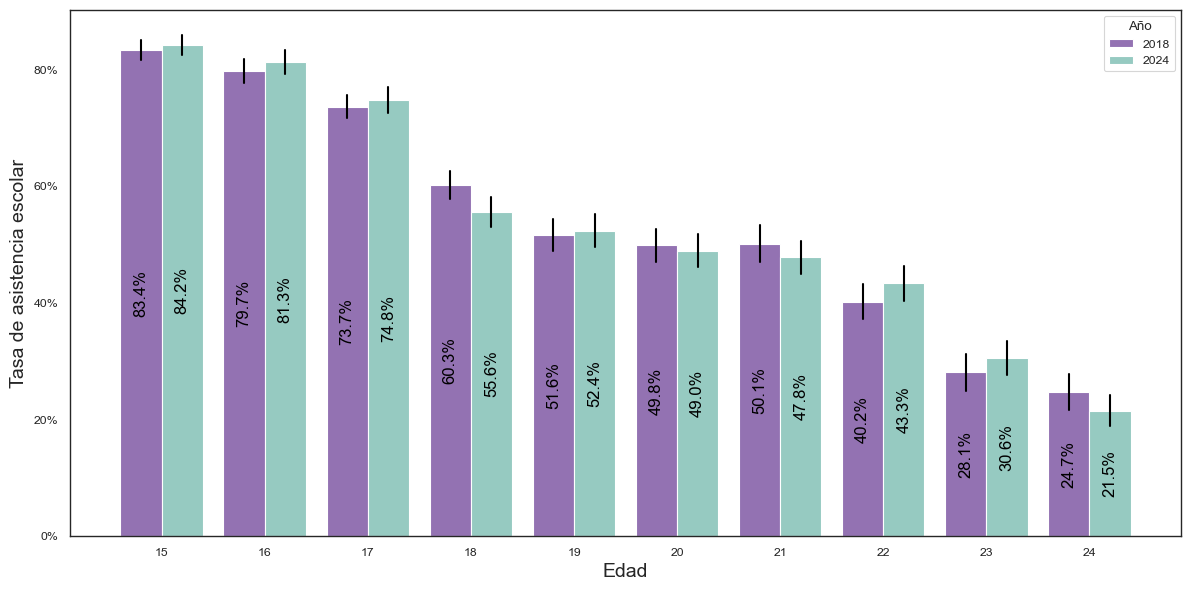

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
import pandas as pd

# === CARGAR DATOS ===
ruta = r"data/processed/Estadistica descriptiva.xlsx"
hoja = "Asis_esc por edades"

df = pd.read_excel(ruta, sheet_name=hoja, header=0)

# Limpiar nombres de columnas
df.columns = df.columns.str.strip()

# === CONFIGURACIÓN ESTÉTICA ===
sns.set(style="white", context="paper")
plt.figure(figsize=(12, 6))

# === GRAFICAR BARRAS ===
ax = sns.barplot(
    data=df,
    x="Edad",
    y="Media",
    hue="Anio",
    ci=None,
    palette= ["#9467bd", "#8dd3c7"]
)

# === AÑADIR LÍNEAS DE INTERVALO DE CONFIANZA ===
for i, row in df.iterrows():
    x_pos = list(df["Edad"].unique()).index(row["Edad"])
    offset = -0.2 if row["Anio"] == 2018 else 0.2
    ax.plot(
        [x_pos + offset, x_pos + offset],
        [row["Intervalo de confianza inferior"], row["Intervalo de confianza superior"]],
        color="black",
        linewidth=1.5
    )

# === AÑADIR ETIQUETAS DE PORCENTAJE (VERTICALES) ===
for patch in ax.patches:
    height = patch.get_height()
    if height > 0:  # 👈 Ignora las barras vacías
        x = patch.get_x() + patch.get_width() / 2
        y = height / 2
        ax.text(
            x,
            y,
            f"{height*100:.1f}%",
            ha="center",
            va="center",
            rotation=90,
            color="black",
            fontsize=12
        )

# === FORMATO Y ETIQUETAS ===
ax.yaxis.set_major_formatter(PercentFormatter(1))
plt.xlabel("Edad", fontsize=14)
plt.ylabel("Tasa de asistencia escolar", fontsize=14)
plt.legend(title="Año")
plt.tight_layout()
plt.show()


# Asistencia Escolar por Edades y Sexos


✅ Columnas detectadas y limpiadas:
 ['anio', 'sexo', 'edad', 'media', 'error_estandar_linealizado', 'intervalo_de_confianza_inferior', 'intervalo_de_confianza_superior']


/var/folders/lw/wsksmjcd29scklkcylgwjjlr0000gn/T/ipykernel_59550/1402615117.py:47: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/var/folders/lw/wsksmjcd29scklkcylgwjjlr0000gn/T/ipykernel_59550/1402615117.py:47: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


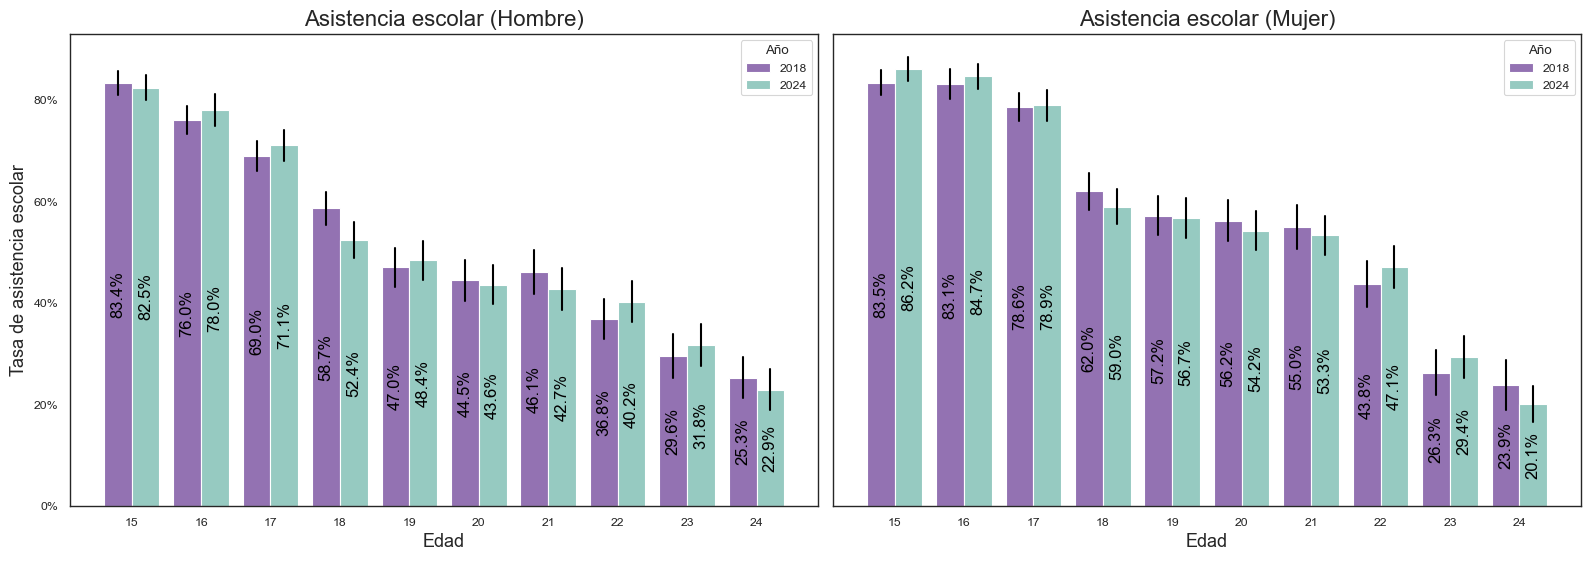

In [16]:
# ==== ASISTENCIA ESCOLAR POR SEXO Y AÑO ====
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
import pandas as pd
import unicodedata

# === CARGAR DATOS ===
ruta = r"data/processed/Estadistica descriptiva.xlsx"
hoja = "Asis_esc por edades y sexo"

df = pd.read_excel(ruta, sheet_name=hoja, header=0)

# === LIMPIAR NOMBRES DE COLUMNAS ===
def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(c for c in unicodedata.normalize("NFD", col) if unicodedata.category(c) != "Mn")
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

print("✅ Columnas detectadas y limpiadas:\n", df.columns.tolist())

# === RENOMBRAR A CLAVES ESTÁNDAR ===
renombres = {
    'anio': 'Anio',
    'sexo': 'Sexo',
    'edad': 'Edad',
    'media': 'Media',
    'error_estandar_linealizado': 'Error',
    'intervalo_de_confianza_inferior': 'IC_inf',
    'intervalo_de_confianza_superior': 'IC_sup'
}
df = df.rename(columns={k: v for k, v in renombres.items() if k in df.columns})

# === CONFIGURACIÓN DE ESTILO ===
sns.set_theme(style="white", context="paper", palette="Set2")

# === CREAR FIGURA CON 2 SUBPLOTS (uno por sexo) ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sexos = ["Hombre", "Mujer"]

for ax, sexo in zip(axes, sexos):
    dff = df[df["Sexo"].str.lower().str.contains(sexo.lower())]

    sns.barplot(
        data=dff,
        x="Edad",
        y="Media",
        hue="Anio",
        ci=None,
        palette= ["#9467bd", "#8dd3c7"],
        ax=ax
    )

    # === Añadir intervalos de confianza ===
    for i, row in dff.iterrows():
        x_pos = list(dff["Edad"].unique()).index(row["Edad"])
        offset = -0.2 if int(row["Anio"]) == 2018 else 0.2
        ax.plot(
            [x_pos + offset, x_pos + offset],
            [row["IC_inf"], row["IC_sup"]],
            color="black",
            linewidth=1.5
        )

    # === Añadir etiquetas dentro de las barras ===
    for patch in ax.patches:
        height = patch.get_height()
        if height > 0:
            x = patch.get_x() + patch.get_width() / 2
            y = height / 2
            ax.text(
                x, y,
                f"{height*100:.1f}%",
                ha="center", va="center",
                rotation=90,
                color="black",
                fontsize=12
            )

    # === FORMATO ===
    ax.set_title(f"Asistencia escolar ({sexo})", fontsize=16)
    ax.set_xlabel("Edad", fontsize=13)
    ax.set_ylabel("Tasa de asistencia escolar" if sexo == "Hombre" else "", fontsize=13)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.legend(title="Año")

# === TÍTULO GENERAL ===
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [3]:
# ==============================
# PRUEBA DE DIFERENCIAS POR SEXO
# ==============================

import pandas as pd
import numpy as np
from scipy.stats import norm
import unicodedata
import dataframe_image as dfi

# ==========================================
# 1. CARGAR DATOS
# ==========================================

ruta = r"data/processed/Estadistica descriptiva.xlsx"
hoja = "Asis_esc por edades y sexo"

df = pd.read_excel(ruta, sheet_name=hoja)

# ==========================================
# 2. LIMPIAR NOMBRES DE COLUMNAS
# ==========================================

def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(
        c for c in unicodedata.normalize("NFD", col)
        if unicodedata.category(c) != "Mn"
    )
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

# Renombrar columnas de acuerdo con el archivo Excel
renombres = {
    "anio": "Anio",
    "edad": "Edad",
    "sexo": "Sexo",
    "media": "Asiste",
    "error_estandar_linealizado": "Se",
    "intervalo_de_confianza_inferior": "IC_inf",
    "intervalo_de_confianza_superior": "IC_sup"
}

df.rename(columns=renombres, inplace=True)

print("✅ Columnas detectadas:")
print(df.columns.tolist())

# Verificar columnas necesarias
columnas_necesarias = ["Anio", "Edad", "Sexo", "Asiste", "Se"]

faltantes = [c for c in columnas_necesarias if c not in df.columns]

if faltantes:
    raise ValueError(f"Faltan columnas: {faltantes}")

# ==========================================
# 3. PRUEBA DE DIFERENCIA DE PROPORCIONES
# ==========================================

resultados = []

for (anio, edad), grupo in df.groupby(["Anio", "Edad"]):

    # Debe haber dos sexos
    if grupo["Sexo"].nunique() < 2:
        continue

    # Detectar hombres y mujeres
    hombres = grupo[
        grupo["Sexo"].astype(str).str.contains("hom", case=False, na=False)
    ]

    mujeres = grupo[
        grupo["Sexo"].astype(str).str.contains("muj", case=False, na=False)
    ]

    if hombres.empty or mujeres.empty:
        continue

    # Proporciones
    ph = hombres["Asiste"].iloc[0]
    pm = mujeres["Asiste"].iloc[0]

    # Errores estándar
    sh = hombres["Se"].iloc[0]
    sm = mujeres["Se"].iloc[0]

    # Diferencia Hombre - Mujer
    diff = ph - pm

    # Error estándar combinado
    se_comb = np.sqrt(sh**2 + sm**2)

    # Estadístico Z
    z = diff / se_comb if se_comb > 0 else np.nan

    # Valor p bilateral
    p = 2 * (1 - norm.cdf(abs(z))) if not np.isnan(z) else np.nan

    # Intervalo de confianza
    ci_inf = diff - 1.96 * se_comb
    ci_sup = diff + 1.96 * se_comb

    resultados.append({
        "Anio": anio,
        "Edad": edad,
        "Asistencia Hombres": ph,
        "Asistencia Mujeres": pm,
        "Diferencia (H-M)": diff,
        "Error Estándar": se_comb,
        "Z": z,
        "Valor-p": p,
        "IC95% inferior": ci_inf,
        "IC95% superior": ci_sup,
        "Decisión": (
            "Rechazo H0"
            if (not np.isnan(p) and p < 0.05)
            else "No rechazo H0"
        )
    })

# ==========================================
# 4. TABLA DE RESULTADOS
# ==========================================

res_df = pd.DataFrame(resultados)

res_df = res_df.sort_values(["Anio", "Edad"]).reset_index(drop=True)

styled = (
    res_df.style
    .format({
        "Asistencia Hombres": "{:.2%}",
        "Asistencia Mujeres": "{:.2%}",
        "Diferencia (H-M)": "{:.2%}",
        "Error Estándar": "{:.4f}",
        "Z": "{:.2f}",
        "Valor-p": "{:.4f}",
        "IC95% inferior": "{:.2%}",
        "IC95% superior": "{:.2%}",
    })
    .map(
        lambda x:
            "background-color: lightgreen; color:black"
            if x == "Rechazo H0"
            else (
                "background-color: salmon; color:black"
                if x == "No rechazo H0"
                else ""
            ),
        subset=["Decisión"]
    )
    .background_gradient(
        subset=["Valor-p"],
        cmap="RdYlGn_r"
    )
    .set_properties(**{
        "text-align": "center",
        "font-family": "Arial",
        "font-size": "11pt"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("background-color", "#f2f2f2"),
                ("font-weight", "bold"),
            ],
        },
        {
            "selector": "td",
            "props": [("padding", "6px")],
        },
    ])
)

display(styled)

# ==========================================
# 5. EXPORTAR TABLA
# ==========================================

dfi.export(
    styled,
    "tabla_tesis_proporciones_sexo.png",
    table_conversion="chrome"
)

print("✅ Tabla exportada como:")
print("tabla_tesis_proporciones_sexo.png")

✅ Columnas detectadas:
['Anio', 'Sexo', 'Edad', 'Asiste', 'Se', 'IC_inf', 'IC_sup']


,Anio,Edad,Asistencia Hombres,Asistencia Mujeres,Diferencia (H-M),Error Estándar,Z,Valor-p,IC95% inferior,IC95% superior,Decisión
0,2018,15,83.36%,83.45%,-0.09%,0.0175,-0.05,0.9579,-3.51%,3.33%,No rechazo H0
1,2018,16,76.03%,83.14%,-7.11%,0.0204,-3.48,0.0005,-11.11%,-3.10%,Rechazo H0
2,2018,17,69.02%,78.60%,-9.58%,0.0210,-4.56,0.0000,-13.69%,-5.46%,Rechazo H0
3,2018,18,58.66%,61.99%,-3.33%,0.0245,-1.36,0.1741,-8.12%,1.47%,No rechazo H0
4,2018,19,47.01%,57.23%,-10.21%,0.0280,-3.65,0.0003,-15.71%,-4.72%,Rechazo H0
5,2018,20,44.46%,56.21%,-11.75%,0.0290,-4.05,0.0001,-17.43%,-6.07%,Rechazo H0
6,2018,21,46.07%,54.98%,-8.91%,0.0311,-2.86,0.0042,-15.01%,-2.81%,Rechazo H0
7,2018,22,36.79%,43.78%,-7.00%,0.0308,-2.27,0.0232,-13.04%,-0.95%,Rechazo H0
8,2018,23,29.55%,26.29%,3.26%,0.0314,1.04,0.2982,-2.89%,9.42%,No rechazo H0
9,2018,24,25.31%,23.87%,1.44%,0.0324,0.44,0.6576,-4.91%,7.78%,No rechazo H0


✅ Tabla exportada como:
tabla_tesis_proporciones_sexo.png


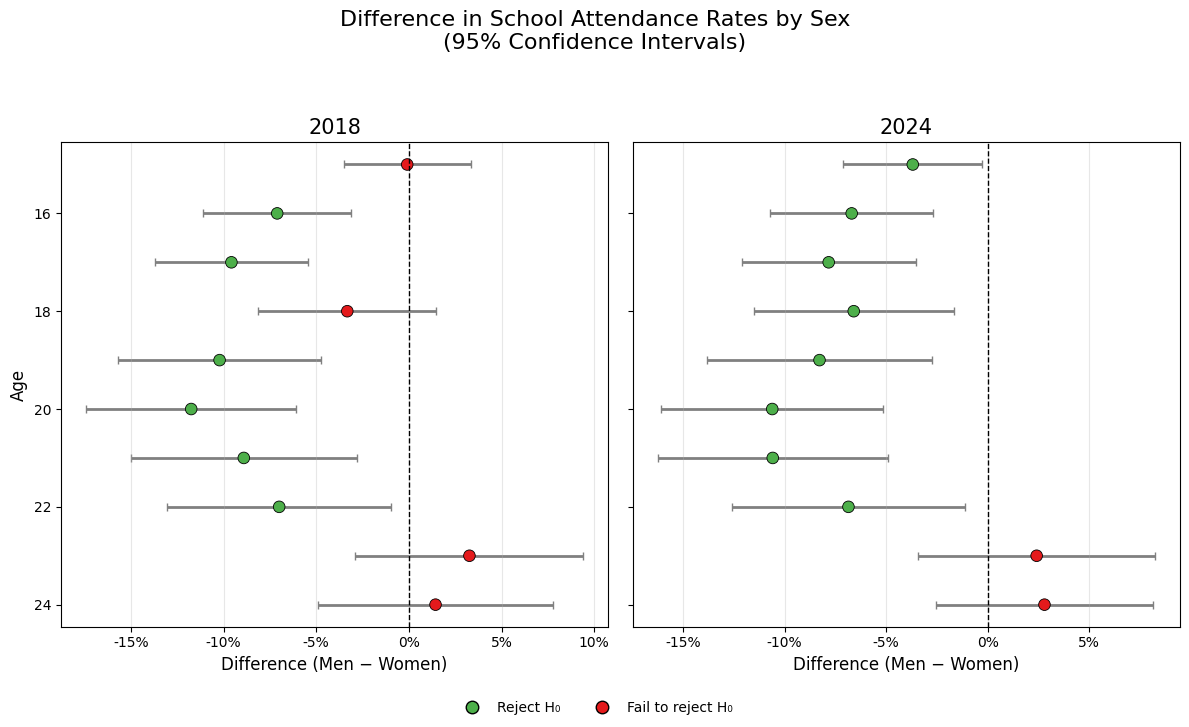

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# ============================================
# PREPARE DATA
# ============================================

graf = res_df.copy()

# Keep only numeric ages (in case there is a "Total" row)
graf = graf[pd.to_numeric(graf["Edad"], errors="coerce").notna()].copy()
graf["Edad"] = graf["Edad"].astype(int)

graf = graf.sort_values(["Anio", "Edad"])

# ============================================
# FIGURE
# ============================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 7),
    sharey=True
)

years = sorted(graf["Anio"].unique())

for ax, year in zip(axes, years):

    df_year = graf[graf["Anio"] == year].copy()

    # Green = significant
    # Red = not significant
    colors = df_year["Decisión"].map({
        "Rechazo H0": "#4daf4a",
        "No rechazo H0": "#e41a1c"
    })

    # Horizontal confidence intervals
    lower = df_year["Diferencia (H-M)"] - df_year["IC95% inferior"]
    upper = df_year["IC95% superior"] - df_year["Diferencia (H-M)"]

    ax.errorbar(
        df_year["Diferencia (H-M)"],
        df_year["Edad"],
        xerr=[lower, upper],
        fmt="none",
        ecolor="gray",
        elinewidth=2,
        capsize=3,
        zorder=1
    )

    # Estimated differences
    ax.scatter(
        df_year["Diferencia (H-M)"],
        df_year["Edad"],
        s=70,
        c=colors,
        edgecolor="black",
        linewidth=0.6,
        zorder=2
    )

    # Null hypothesis line
    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1
    )

    ax.set_title(f"{year}", fontsize=15)

    ax.set_xlabel(
        "Difference (Men − Women)",
        fontsize=12
    )

    ax.grid(
        axis="x",
        alpha=0.3
    )

axes[0].set_ylabel("Age", fontsize=12)

# Put age 15 at the top
axes[0].invert_yaxis()

# Percent labels
for ax in axes:
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, pos: f"{x:.0%}")
    )

# ============================================
# LEGEND
# ============================================

from matplotlib.lines import Line2D

legend = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor="#4daf4a",
        markeredgecolor="black",
        markersize=9,
        label="Reject H₀"
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor="#e41a1c",
        markeredgecolor="black",
        markersize=9,
        label="Fail to reject H₀"
    )
]

fig.legend(
    handles=legend,
    loc="lower center",
    ncol=2,
    frameon=False
)

fig.suptitle(
    "Difference in School Attendance Rates by Sex\n(95% Confidence Intervals)",
    fontsize=16,
    y=1.02
)

plt.tight_layout(rect=[0, 0.05, 1, 0.97])

plt.savefig(
    "forestplot_sexo.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Analisis Escolar por total de integrantes

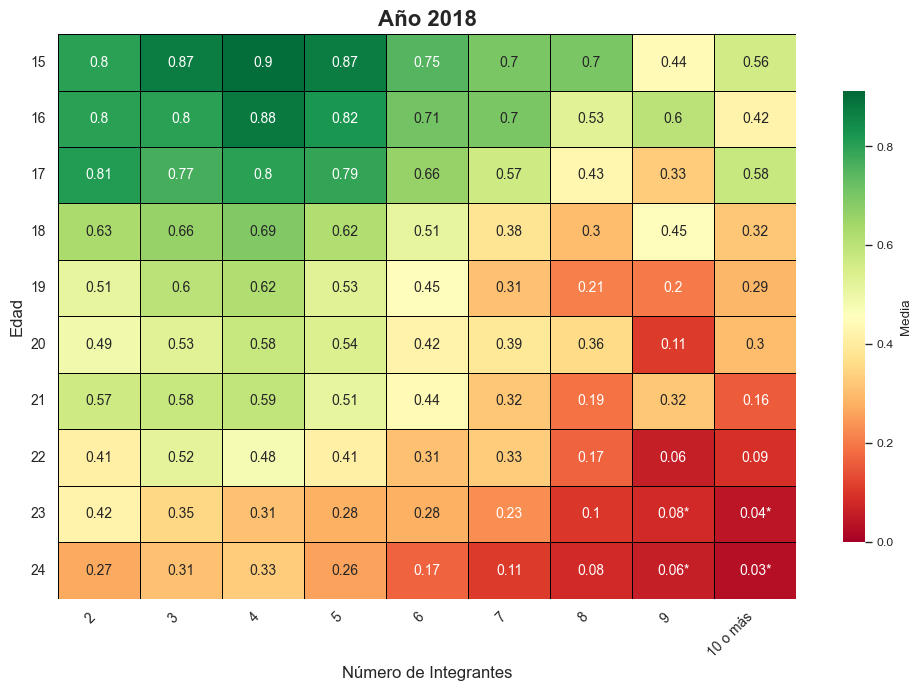

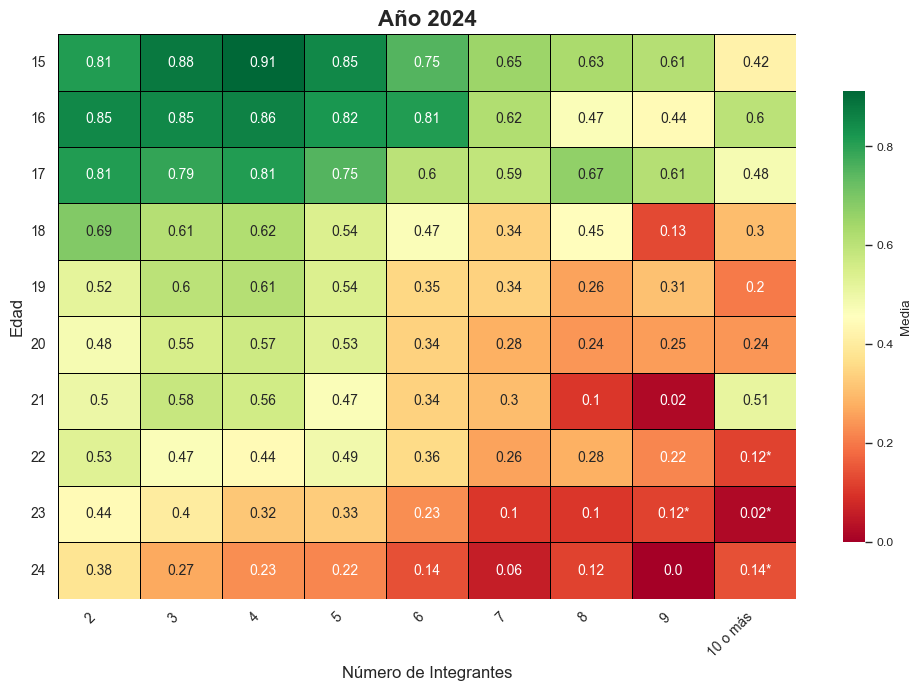

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import unicodedata

# === CARGAR DATOS ===
ruta = r"data/processed/Estadistica descriptiva.xlsx"
hoja = "Asis_esc por edades e integrant"
df = pd.read_excel(ruta, sheet_name=hoja, header=0)

# === LIMPIAR NOMBRES DE COLUMNAS ===
def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(c for c in unicodedata.normalize("NFD", col) if unicodedata.category(c) != "Mn")
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

# Renombrar columnas
df.rename(columns={
    "anio": "Anio",
    "integrantes": "Integrantes",
    "edad": "Edad",
    "media": "Media",
    "intervalo_de_confianza_inferior": "IC_inf",
    "intervalo_de_confianza_superior": "IC_sup"
}, inplace=True)

# Mapear columna 'Integrantes' a número
df["Integrantes_num"] = df["Integrantes"].replace({"10 o mas": 10}).astype(int)

col_nums = list(range(2,11))  # del 2 al 10
col_labels = [2,3,4,5,6,7,8,9,"10 o más"]

# Rango de color común
vmin = df["Media"].min()
vmax = df["Media"].max()

# Función para heatmap con asteriscos de no significancia
def plot_heatmap_significance(df, year):
    df_year = df[df["Anio"] == year]
    
    # Pivot de Media
    heatmap_data = df_year.pivot(index="Edad", columns="Integrantes_num", values="Media")
    heatmap_data = heatmap_data[[c for c in col_nums if c in heatmap_data.columns]].round(2)
    heatmap_data.rename(columns={10: "10 o más"}, inplace=True)
    
    # Crear DataFrame de anotaciones (mismo tamaño que heatmap)
    annot = heatmap_data.copy().astype(str)
    
    for edad in heatmap_data.index:
        for col in heatmap_data.columns:
            # Mapear columna de vuelta a número para verificar IC
            col_num = col if col != "10 o más" else 10
            # Buscar fila correspondiente
            fila = df_year[(df_year["Edad"]==edad) & (df_year["Integrantes_num"]==col_num)]
            if not fila.empty:
                ic_inf = fila["IC_inf"].values[0]
                ic_sup = fila["IC_sup"].values[0]
                # Si el intervalo incluye cero, agregar asterisco
                if ic_inf <= 0 <= ic_sup:
                    annot.loc[edad, col] += "*"

    # Crear figura
    plt.figure(figsize=(10,7))
    sns.heatmap(
        heatmap_data,
        annot=annot,
        fmt="",
        cmap="RdYlGn",
        vmin=vmin,
        vmax=vmax,
        linewidths=0.5,
        linecolor="black",
        annot_kws={"size":10},
        cbar_kws={'label':'Media', "shrink":0.8}
    )
    plt.title(f"Año {year}", fontsize=16, fontweight="bold")
    plt.xlabel("Número de Integrantes", fontsize=12)
    plt.ylabel("Edad", fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()

# Ejemplo
plot_heatmap_significance(df, 2018)
plot_heatmap_significance(df, 2024)


# Analisis Escolar por Ingreso

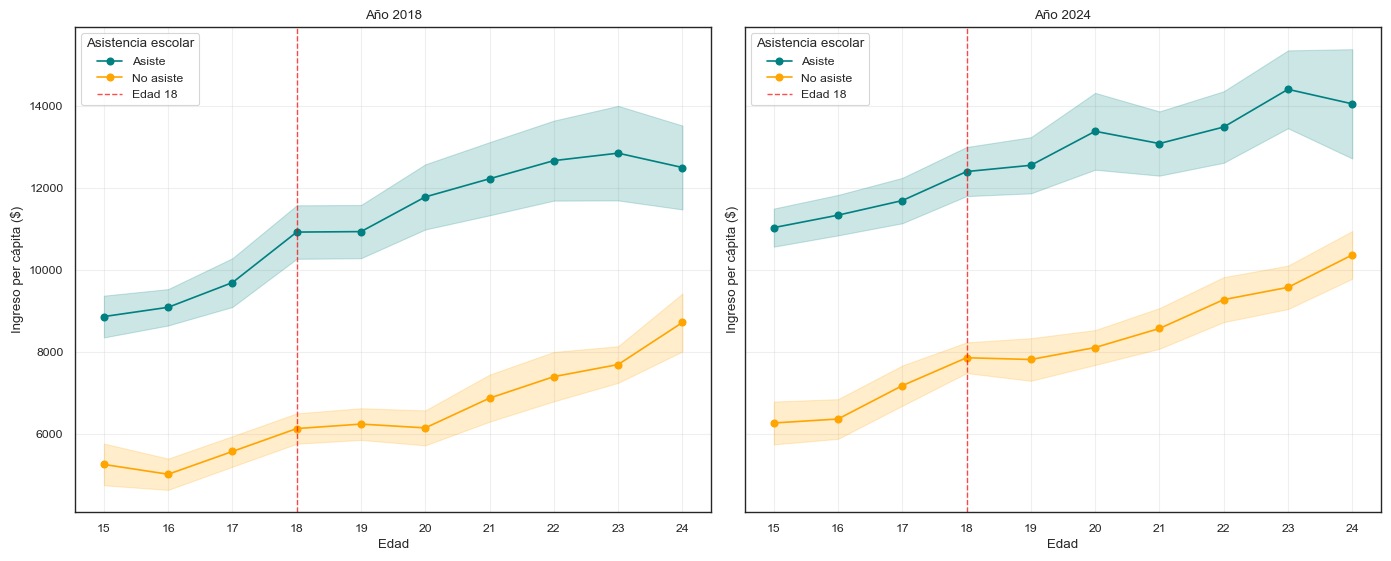

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np # Necesario para generar las marcas de 1 en 1

# =============================
# 1. Cargar archivo Excel
# =============================
ruta = r"data/processed/Estadistica descriptiva.xlsx"

df = pd.read_excel(ruta, sheet_name="Ingreso por asistencia y edad")

# =============================
# 2. Filtrar solo “No” en la columna de aportación
# =============================
df = df[df["Contando aportacion de jovenes"] == "No"]

# =============================
# 3. Limpieza básica
# =============================
cols_numericas = [
    "Media",
    "Error Estandar Linealizado",
    "Intervalo de confianza inferior",
    "Intervalo de confianza superior"
]

for c in cols_numericas:
    # Aseguramos que la columna sea numérica después de limpiar
    df[c] = df[c].replace(r"[\$,]", "", regex=True).astype(float)

# =============================
# 4. Función para graficar en un eje específico
# =============================
def plot_por_anio(df, anio, ax):
    df_anio = df[df["Anio"] == anio]

    for grupo, color in zip(["Asiste", "No asiste"], ["teal", "orange"]):
        df_g = df_anio[df_anio["Asistencia"] == grupo]

        # Línea principal (media)
        ax.plot(
            df_g["Edad"],
            df_g["Media"],
            label=f"{grupo}",
            color=color,
            marker="o"
        )

        # Banda de confianza (IC 95%)
        ax.fill_between(
            df_g["Edad"],
            df_g["Intervalo de confianza inferior"],
            df_g["Intervalo de confianza superior"],
            color=color,
            alpha=0.2
        )

    # Línea vertical en edad 18
    ax.axvline(x=18, color="red", linestyle="--", linewidth=1, alpha=0.7, label="Edad 18")

    # --- INSERCIÓN DEL CÓDIGO PARA FORZAR MARCAS EN EL EJE X DE 1 EN 1 ---
    # Calculamos el rango de edades para este subgráfico (este DataFrame ya está filtrado)
    min_edad = df_anio['Edad'].min()
    max_edad = df_anio['Edad'].max()
    marcas_x = np.arange(min_edad, max_edad + 1)
    
    # Aplicar las marcas al eje X del subplot actual (ax)
    ax.set_xticks(marcas_x)
    # ----------------------------------------------------------------------
    
    # Etiquetas y título
    ax.set_title(f"Año {anio}")
    ax.set_xlabel("Edad")
    ax.set_ylabel("Ingreso per cápita ($)")
    ax.grid(alpha=0.3)
    ax.legend(title="Asistencia escolar", loc="upper left")

# =============================
# 5. Crear figura con dos subplots
# =============================
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

plot_por_anio(df, 2018, axes[0])
plot_por_anio(df, 2024, axes[1])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [46]:
# ======================================
# PRUEBA DE DIFERENCIAS – APORTACIÓN JÓVENES
# ======================================

import pandas as pd
import numpy as np
from scipy.stats import norm
import unicodedata

# === 1. Cargar datos ===
ruta = r"data/processed/Estadistica descriptiva.xlsx"
hoja = "Ingreso por asistencia y edad"

df = pd.read_excel(ruta, sheet_name=hoja)

# === 2. Normalizar nombres de columnas ===
def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(c for c in unicodedata.normalize("NFD", col) if unicodedata.category(c) != "Mn")
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

# Renombrar para facilitar el acceso
renombres = {
    "anio": "Anio",
    "año": "Anio",
    "edad": "Edad",
    "asistencia": "Asistencia",
    "contando_aportacion_de_jovenes": "Contando_aportacion_de_jovenes",
    "media": "Media",
    "error_estandar_linealizado": "Se"
}
df = df.rename(columns={k: v for k, v in renombres.items() if k in df.columns})

# === 3. Limpiar formato numérico de variables de ingreso ===
df["Media"] = df["Media"].replace(r"[\$,]", "", regex=True).astype(float)
df["Se"] = df["Se"].replace(r"[\$,]", "", regex=True).astype(float)

# === 4. Calcular diferencias entre "Sí" y "No" por edad, año y asistencia ===
resultados = []

for (anio, edad, asistencia), grupo in df.groupby(["Anio", "Edad", "Asistencia"]):

    if len(grupo["Contando_aportacion_de_jovenes"].unique()) < 2:
        continue  # debe haber ambos grupos

    grupo_si = grupo[grupo["Contando_aportacion_de_jovenes"].str.lower() == "si"]
    grupo_no = grupo[grupo["Contando_aportacion_de_jovenes"].str.lower() == "no"]

    if len(grupo_si) == 0 or len(grupo_no) == 0:
        continue

    media_si = grupo_si["Media"].values[0]
    media_no = grupo_no["Media"].values[0]
    se_si = grupo_si["Se"].values[0]
    se_no = grupo_no["Se"].values[0]

    diff = media_si - media_no
    se_comb = np.sqrt(se_si**2 + se_no**2)
    z = diff / se_comb if se_comb > 0 else np.nan
    p_valor = 2 * (1 - norm.cdf(abs(z))) if not np.isnan(z) else np.nan

    ci_low = diff - 1.96 * se_comb
    ci_high = diff + 1.96 * se_comb

    resultados.append({
        "Año": anio,
        "Edad": edad,
        "Asistencia": asistencia,
        "Media (Sí)": media_si,
        "Media (No)": media_no,
        "Diferencia (Sí - No)": diff,
        "Error Estándar": se_comb,
        "Z": z,
        "Valor-p": p_valor,
        "IC95% inferior": ci_low,
        "IC95% superior": ci_high,
        "Decisión": "Rechazo H0" if (not np.isnan(p_valor) and p_valor < 0.05) else "No rechazo H0"
    })

res_df = pd.DataFrame(resultados)

# === 5. Formato de salida bonito ===
import dataframe_image as dfi

styled = (
    res_df.style
    .format({
        "Media (Sí)": "${:,.2f}".format,
        "Media (No)": "${:,.2f}".format,
        "Diferencia (Sí - No)": "${:,.2f}".format,
        "Error Estándar": "{:.3f}".format,
        "Z": "{:.2f}".format,
        "Valor-p": "{:.4f}".format,
        "IC95% inferior": "${:,.2f}".format,
        "IC95% superior": "${:,.2f}".format
    })
    .map(
        lambda x: "background-color: lightgreen; color: black" if x == "Rechazo H0"
                  else ("background-color: salmon; color: black" if x == "No rechazo H0" else ""),
        subset=["Decisión"]
    )
    .background_gradient(subset=["Valor-p"], cmap="RdYlGn_r")
    .set_properties(**{
        "text-align": "center",
        "font-family": "Arial",
        "font-size": "11pt"
    })
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center"),
                                     ("font-size", "11pt"),
                                     ("background-color", "#f2f2f2"),
                                     ("font-weight", "bold")]},
        {"selector": "td", "props": [("padding", "6px")]}
    ])
)

display(styled)

# === 6. Guardar tabla como imagen ===
dfi.export(styled, "tabla_diferencias_aportacion_jovenes.png", table_conversion="chrome")
print("✅ Tabla exportada como 'tabla_diferencias_aportacion_jovenes.png'")


,Año,Edad,Asistencia,Media (Sí),Media (No),Diferencia (Sí - No),Error Estándar,Z,Valor-p,IC95% inferior,IC95% superior,Decisión
0,2018,15,Asiste,"$9,994.14","$8,858.81","$1,135.33",364.438,3.12,0.0018,$421.04,"$1,849.63",Rechazo H0
1,2018,15,No asiste,"$6,984.84","$5,251.93","$1,732.90",393.246,4.41,0.0000,$962.14,"$2,503.67",Rechazo H0
2,2018,16,Asiste,"$10,305.42","$9,084.95","$1,220.47",318.975,3.83,0.0001,$595.28,"$1,845.66",Rechazo H0
3,2018,16,No asiste,"$7,180.68","$5,011.93","$2,168.76",307.064,7.06,0.0000,"$1,566.91","$2,770.60",Rechazo H0
4,2018,17,Asiste,"$10,971.69","$9,688.04","$1,283.65",454.055,2.83,0.0047,$393.70,"$2,173.60",Rechazo H0
5,2018,17,No asiste,"$8,008.48","$5,567.87","$2,440.61",289.764,8.42,0.0000,"$1,872.67","$3,008.54",Rechazo H0
6,2018,18,Asiste,"$12,407.91","$10,919.83","$1,488.08",470.111,3.17,0.0015,$566.66,"$2,409.50",Rechazo H0
7,2018,18,No asiste,"$8,773.56","$6,126.46","$2,647.10",278.519,9.50,0.0000,"$2,101.21","$3,193.00",Rechazo H0
8,2018,19,Asiste,"$12,785.14","$10,931.25","$1,853.89",477.934,3.88,0.0001,$917.14,"$2,790.64",Rechazo H0
9,2018,19,No asiste,"$9,294.22","$6,235.87","$3,058.34",306.560,9.98,0.0000,"$2,457.49","$3,659.20",Rechazo H0


✅ Tabla exportada como 'tabla_diferencias_aportacion_jovenes.png'


/var/folders/lw/wsksmjcd29scklkcylgwjjlr0000gn/T/ipykernel_59550/886746987.py:159: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig(
/Users/jesussanchez/Documents/Pre-trabajo/4.-Multidimensional-School-Attendance-Modeling-Framework/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


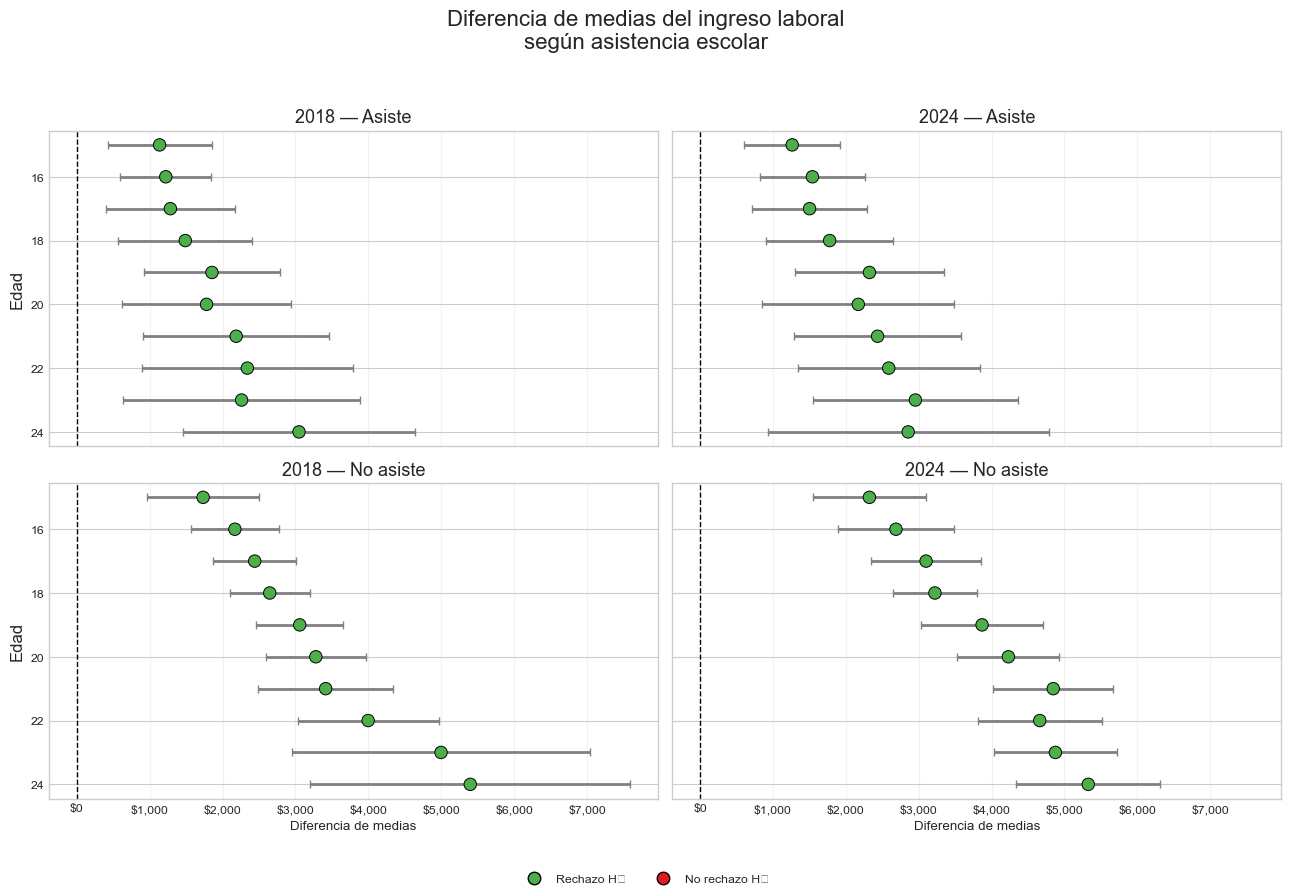

In [49]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

# ==========================================
# PREPARAR DATOS
# ==========================================

graf = res_df.copy()

graf = graf[pd.to_numeric(graf["Edad"], errors="coerce").notna()].copy()
graf["Edad"] = graf["Edad"].astype(int)
graf["Anio"] = graf["Año"].astype(str)

graf = graf.sort_values(["Año", "Asistencia", "Edad"])

# ==========================================
# FIGURA
# ==========================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13,9),
    sharex=True,
    sharey=True
)

years = sorted(graf["Anio"].unique())
asistencias = sorted(graf["Asistencia"].unique())

for i, asistencia in enumerate(asistencias):

    for j, year in enumerate(years):

        ax = axes[i, j]

        df_plot = graf[
            (graf["Anio"] == year) &
            (graf["Asistencia"] == asistencia)
        ].copy()

        colores = df_plot["Decisión"].map({
            "Rechazo H0":"#4daf4a",
            "No rechazo H0":"#e41a1c"
        })

        lower = (
            df_plot["Diferencia (Sí - No)"]
            - df_plot["IC95% inferior"]
        )

        upper = (
            df_plot["IC95% superior"]
            - df_plot["Diferencia (Sí - No)"]
        )

        # Intervalos
        ax.errorbar(
            df_plot["Diferencia (Sí - No)"],
            df_plot["Edad"],
            xerr=[lower, upper],
            fmt="none",
            ecolor="gray",
            elinewidth=2,
            capsize=3,
            zorder=1
        )

        # Puntos
        ax.scatter(
            df_plot["Diferencia (Sí - No)"],
            df_plot["Edad"],
            s=80,
            c=colores,
            edgecolor="black",
            linewidth=0.7,
            zorder=2
        )

        # Hipótesis nula
        ax.axvline(
            0,
            color="black",
            linestyle="--",
            linewidth=1
        )

        ax.grid(
            axis="x",
            alpha=0.25
        )

        ax.set_title(
            f"{year} — {asistencia}",
            fontsize=13
        )

# ==========================================
# FORMATO
# ==========================================

axes[0,0].set_ylabel("Edad", fontsize=12)
axes[1,0].set_ylabel("Edad", fontsize=12)

axes[1,0].set_xlabel("Diferencia de medias")
axes[1,1].set_xlabel("Diferencia de medias")

axes[0,0].invert_yaxis()

formatter = FuncFormatter(lambda x, pos: f"${x:,.0f}")

for ax in axes.ravel():
    ax.xaxis.set_major_formatter(formatter)

# ==========================================
# LEYENDA
# ==========================================

legend = [

    Line2D(
        [0],[0],
        marker='o',
        color='w',
        markerfacecolor="#4daf4a",
        markeredgecolor="black",
        markersize=9,
        label="Rechazo H₀"
    ),

    Line2D(
        [0],[0],
        marker='o',
        color='w',
        markerfacecolor="#e41a1c",
        markeredgecolor="black",
        markersize=9,
        label="No rechazo H₀"
    )

]

fig.legend(
    handles=legend,
    loc="lower center",
    ncol=2,
    frameon=False
)

fig.suptitle(
    "Diferencia de medias del ingreso laboral\nsegún asistencia escolar",
    fontsize=16
)

plt.tight_layout(rect=[0,0.05,1,0.95])

plt.savefig(
    "forestplot_ingresos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/var/folders/lw/wsksmjcd29scklkcylgwjjlr0000gn/T/ipykernel_59550/1209738154.py:210: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig(
/Users/jesussanchez/Documents/Pre-trabajo/4.-Multidimensional-School-Attendance-Modeling-Framework/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


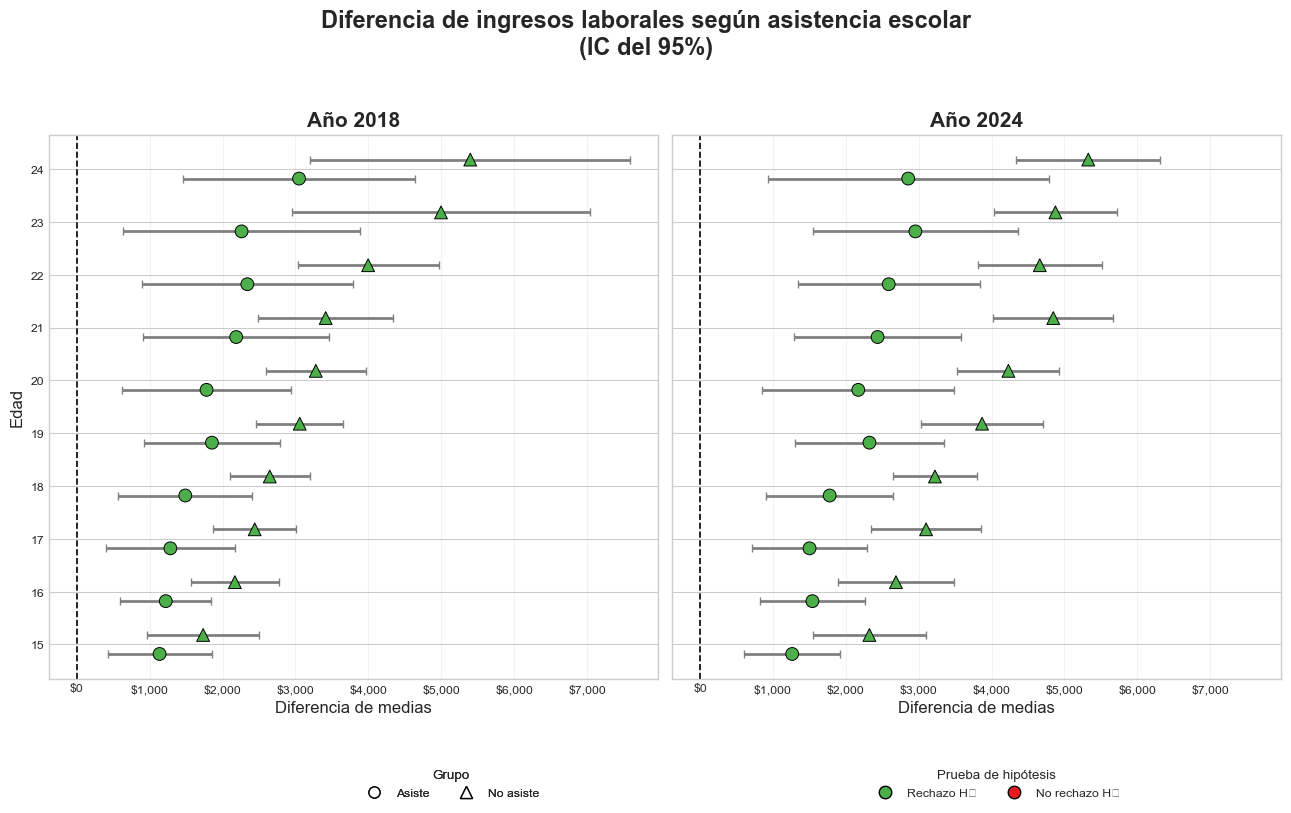

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

# ==========================================
# PREPARAR DATOS
# ==========================================

graf = res_df.copy()

graf = graf[pd.to_numeric(graf["Edad"], errors="coerce").notna()].copy()
graf["Edad"] = graf["Edad"].astype(int)
graf["Año"] = graf["Año"].astype(str)

graf = graf.sort_values(["Año","Edad","Asistencia"])

# ==========================================
# FIGURA
# ==========================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13,8),
    sharey=True,
    sharex=True
)

years = sorted(graf["Año"].unique())

# desplazamiento vertical
offset = {
    "Asiste":-0.18,
    "Sí":-0.18,
    "Si":-0.18,
    "No asiste":0.18,
    "No":0.18
}

# marcadores
markers = {
    "Asiste":"o",
    "Sí":"o",
    "Si":"o",
    "No asiste":"^",
    "No":"^"
}

for ax, year in zip(axes, years):

    datos = graf[graf["Año"]==year]

    for asistencia in datos["Asistencia"].unique():

        d = datos[datos["Asistencia"]==asistencia].copy()

        # posición vertical
        y = d["Edad"] + offset.get(asistencia,0)

        colores = d["Decisión"].map({
            "Rechazo H0":"#4daf4a",
            "No rechazo H0":"#e41a1c"
        })

        # IC
        lower = d["Diferencia (Sí - No)"] - d["IC95% inferior"]
        upper = d["IC95% superior"] - d["Diferencia (Sí - No)"]

        ax.errorbar(
            d["Diferencia (Sí - No)"],
            y,
            xerr=[lower,upper],
            fmt="none",
            ecolor="gray",
            capsize=3,
            elinewidth=2,
            zorder=1
        )

        ax.scatter(
            d["Diferencia (Sí - No)"],
            y,
            s=85,
            marker=markers.get(asistencia,"o"),
            c=colores,
            edgecolor="black",
            linewidth=0.7,
            zorder=2
        )

    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.2
    )

    ax.grid(
        axis="x",
        alpha=0.25
    )

    ax.set_title(
        f"Año {year}",
        fontsize=15,
        weight="bold"
    )

    ax.set_xlabel(
        "Diferencia de medias",
        fontsize=12
    )

# ==========================================
# FORMATO
# ==========================================

axes[0].set_ylabel("Edad",fontsize=12)

for ax in axes:
    ax.set_yticks(sorted(graf["Edad"].unique()))
    ax.invert_yaxis()

formatter = FuncFormatter(lambda x,pos:f"${x:,.0f}")

for ax in axes:
    ax.xaxis.set_major_formatter(formatter)

# ==========================================
# LEYENDAS
# ==========================================

legend1 = [

    Line2D(
        [0],[0],
        marker='o',
        color='black',
        markerfacecolor='white',
        markersize=8,
        linestyle='',
        label='Asiste'
    ),

    Line2D(
        [0],[0],
        marker='^',
        color='black',
        markerfacecolor='white',
        markersize=8,
        linestyle='',
        label='No asiste'
    )
]

legend2 = [

    Line2D(
        [0],[0],
        marker='o',
        color='w',
        markerfacecolor="#4daf4a",
        markeredgecolor="black",
        markersize=9,
        linestyle='',
        label="Rechazo H₀"
    ),

    Line2D(
        [0],[0],
        marker='o',
        color='w',
        markerfacecolor="#e41a1c",
        markeredgecolor="black",
        markersize=9,
        linestyle='',
        label="No rechazo H₀"
    )
]

leg1 = fig.legend(
    handles=legend1,
    loc="lower center",
    bbox_to_anchor=(0.35,-0.02),
    ncol=2,
    frameon=False,
    title="Grupo"
)

leg2 = fig.legend(
    handles=legend2,
    loc="lower center",
    bbox_to_anchor=(0.77,-0.02),
    ncol=2,
    frameon=False,
    title="Prueba de hipótesis"
)

fig.add_artist(leg1)

plt.suptitle(
    "Diferencia de ingresos laborales según asistencia escolar\n(IC del 95%)",
    fontsize=17,
    weight="bold"
)

plt.tight_layout(rect=[0,0.08,1,0.95])

plt.savefig(
    "forestplot_ingresos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Salario por nivel educativo 25-65 años

Generando gráfico para el año 2018...


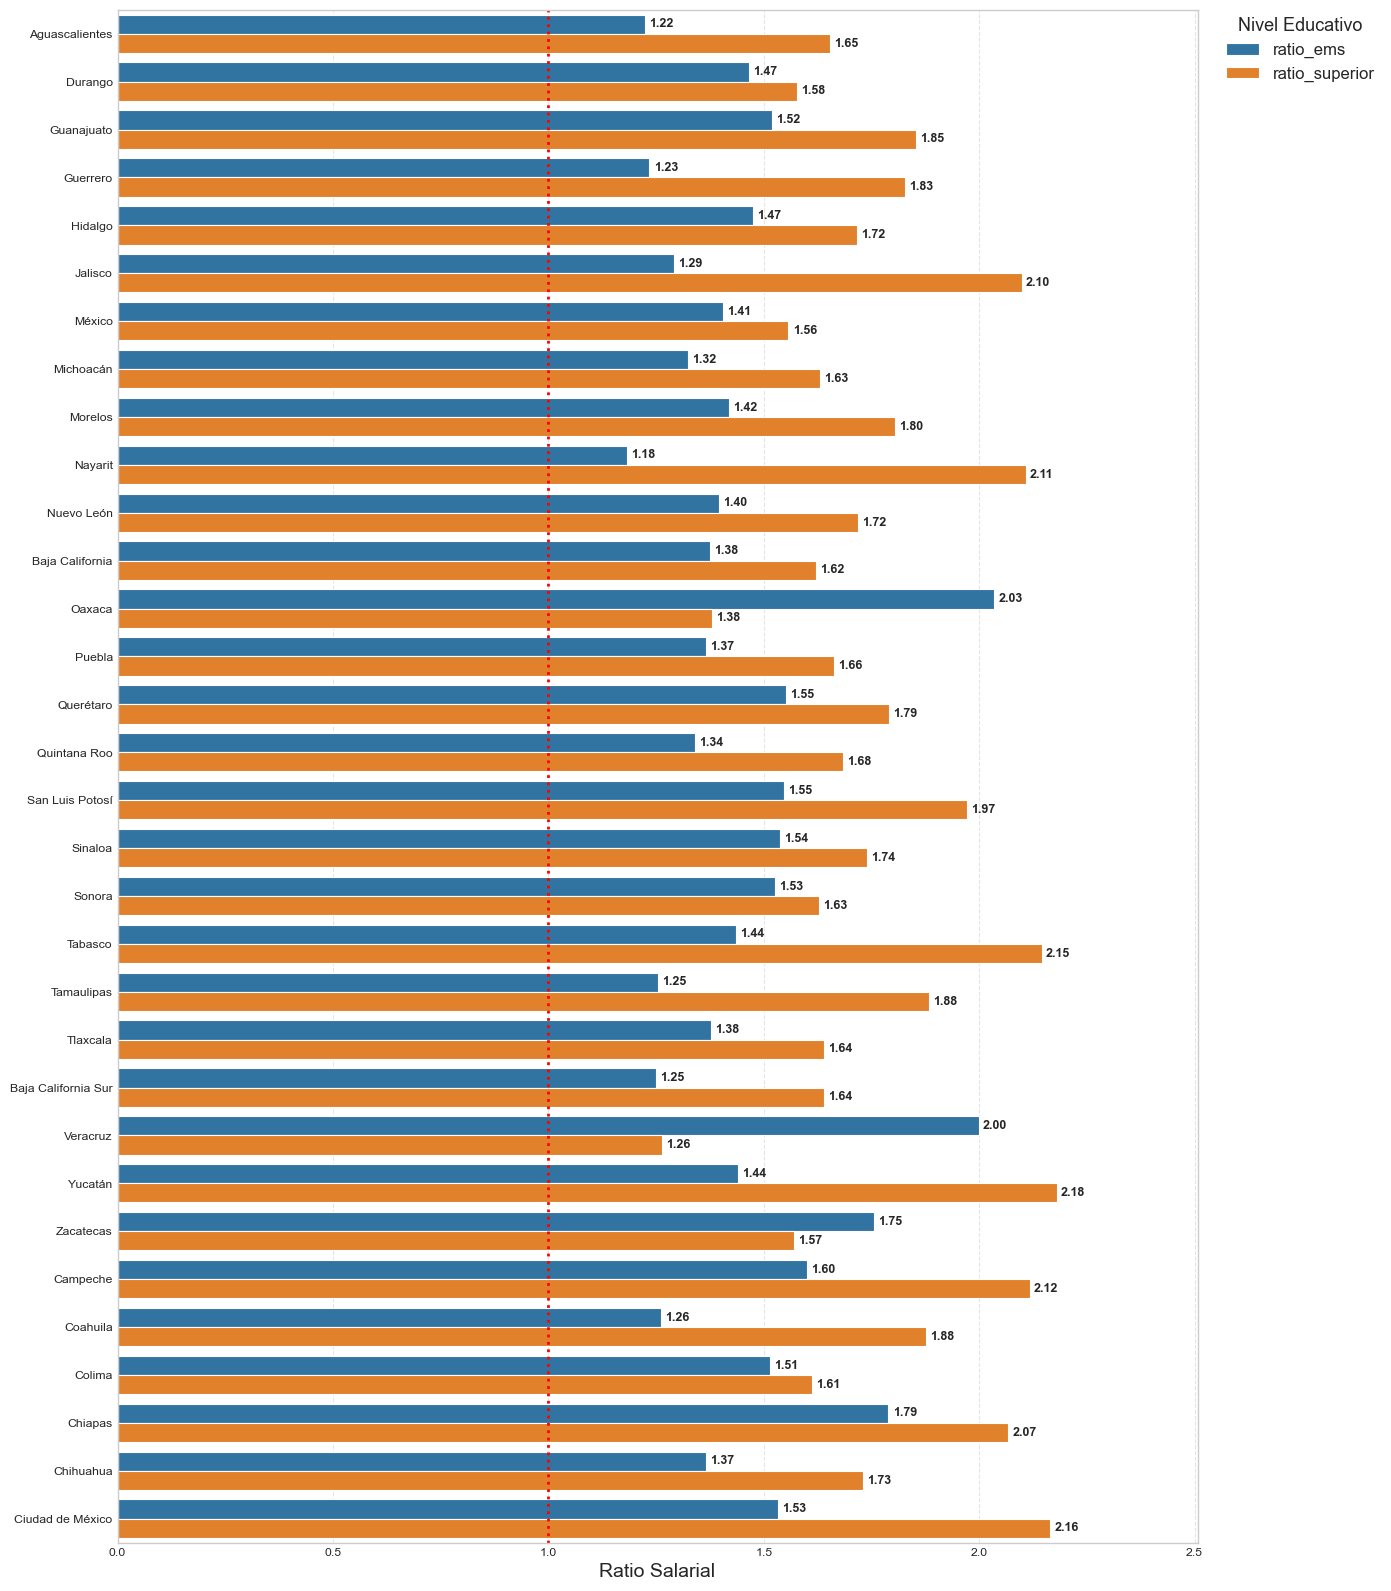

--- Fin del gráfico 2018 ---

Generando gráfico para el año 2024...


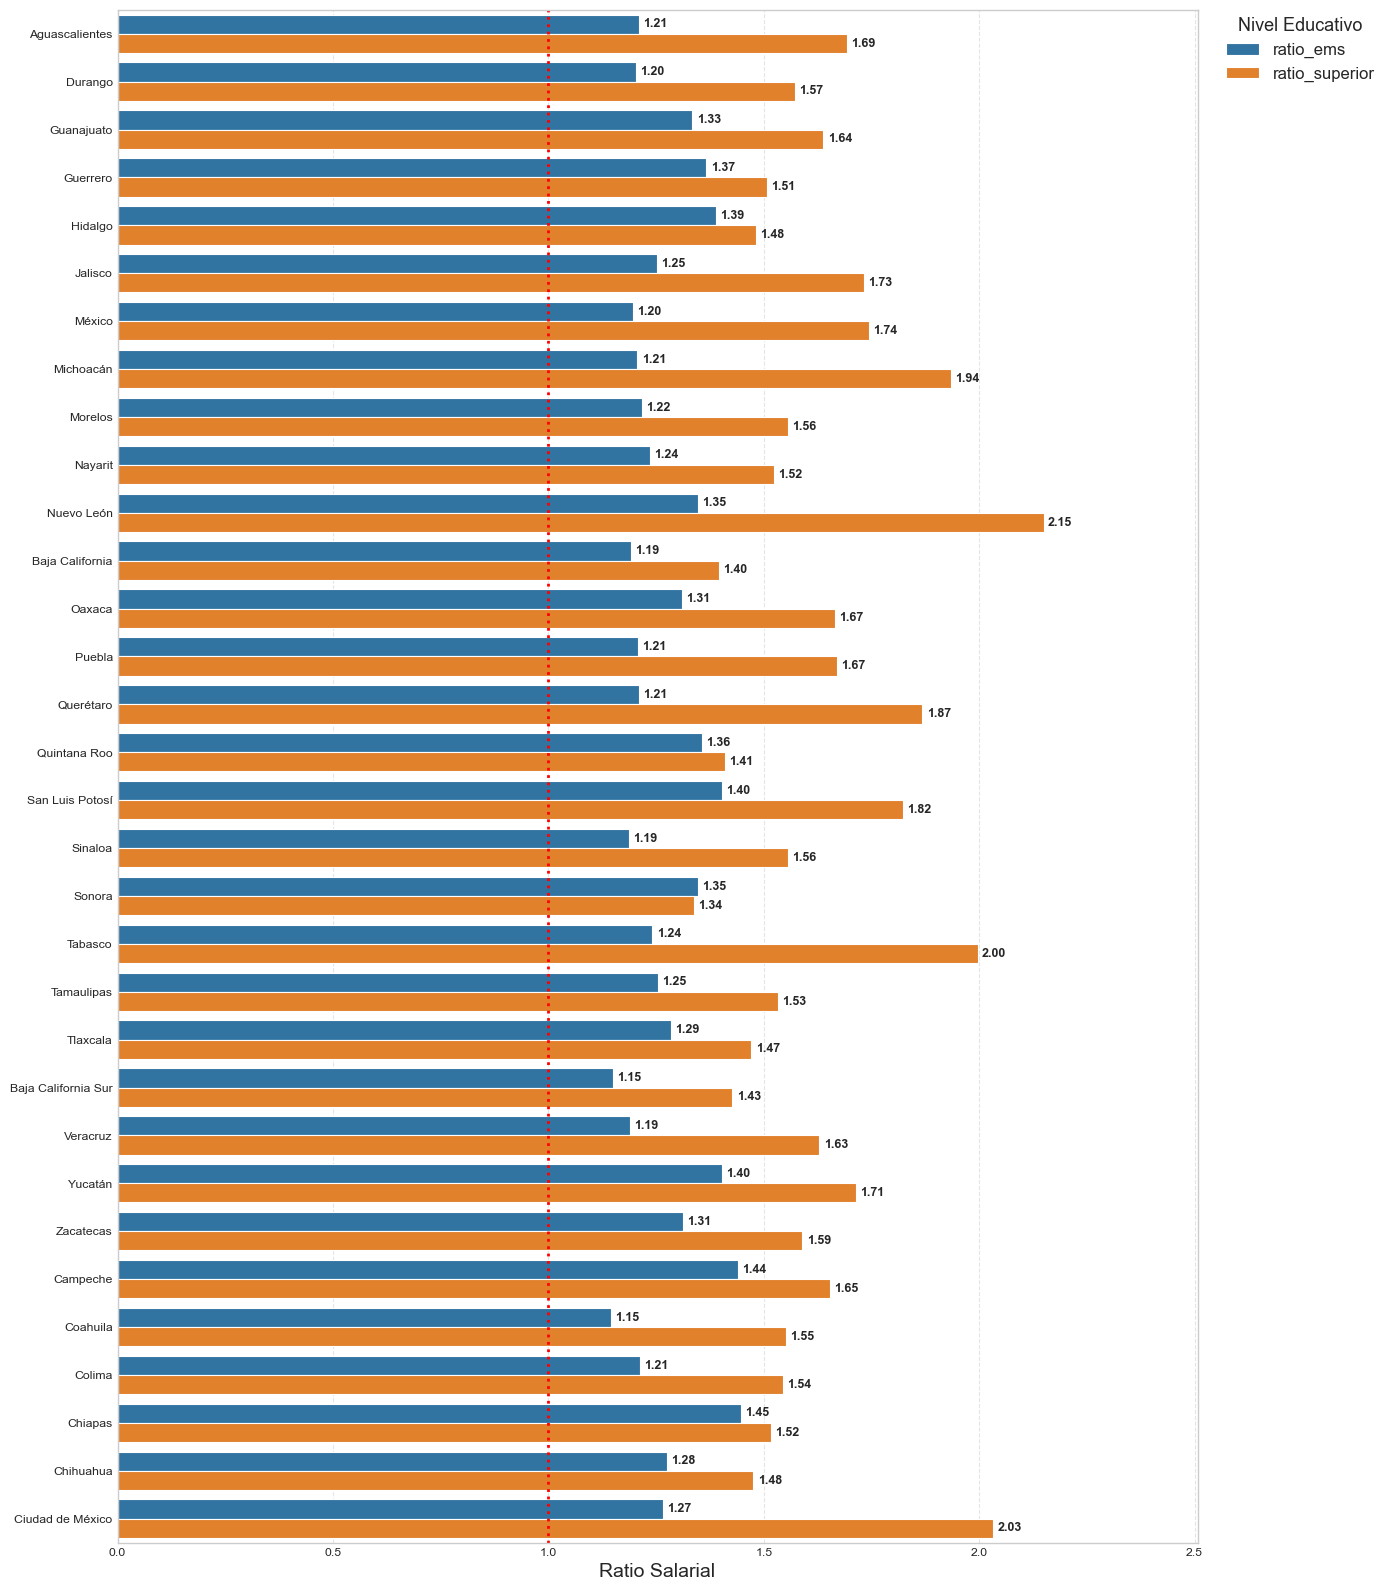

--- Fin del gráfico 2024 ---



In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. CARGA Y PREPARACIÓN ---
ruta = r"data/processed/ratios_salariales_estatales.csv"

try:
    df = pd.read_csv(ruta)
    df.columns = df.columns.str.strip()
    
    estados_inegi = {
        1: 'Aguascalientes', 2: 'Baja California', 3: 'Baja California Sur', 4: 'Campeche',
        5: 'Coahuila', 6: 'Colima', 7: 'Chiapas', 8: 'Chihuahua', 9: 'Ciudad de México',
        10: 'Durango', 11: 'Guanajuato', 12: 'Guerrero', 13: 'Hidalgo', 14: 'Jalisco',
        15: 'México', 16: 'Michoacán', 17: 'Morelos', 18: 'Nayarit', 19: 'Nuevo León',
        20: 'Oaxaca', 21: 'Puebla', 22: 'Querétaro', 23: 'Quintana Roo', 24: 'San Luis Potosí',
        25: 'Sinaloa', 26: 'Sonora', 27: 'Tabasco', 28: 'Tamaulipas', 29: 'Tlaxcala',
        30: 'Veracruz', 31: 'Yucatán', 32: 'Zacatecas'
    }
    df['Nombre_Entidad'] = df['entidad'].map(estados_inegi)

    cols_ratios = ['ratio_ems', 'ratio_superior']
    
    # Calculamos el máximo global para que ambas gráficas tengan la misma escala (Importante para comparar)
    max_valor_global = df[cols_ratios].max().max()

    # --- 2. BUCLE PARA GENERAR AMBOS AÑOS ---
    anios_a_graficar = [2018, 2024]

    for anio in anios_a_graficar:
        print(f"Generando gráfico para el año {anio}...")
        
        # Filtrar y Derretir (Melt)
        df_anio = df[df['anio'] == anio].copy()
        
        df_melted = df_anio.melt(
            id_vars=['Nombre_Entidad'], 
            value_vars=cols_ratios,
            var_name='Nivel Educativo', 
            value_name='Ratio Salarial'
        )

        # Configuración del Gráfico
        plt.figure(figsize=(14, 16))
        
        ax = sns.barplot(
            data=df_melted,
            x='Ratio Salarial',
            y='Nombre_Entidad',
            hue='Nivel Educativo',
            palette='tab10'
        )

        ax.axvline(x=1, color='red', linestyle=':', linewidth=2)

        # Agregar etiquetas numéricas
        for container in ax.containers:
            ax.bar_label(
                container, 
                fmt='%.2f',      
                padding=3,       
                fontsize=9,      
                fontweight='bold' 
            )

        # Títulos y ejes
        #plt.title(f'Ratios Salariales por Entidad Federativa ({anio})', fontsize=18)
        plt.xlabel('Ratio Salarial', fontsize=14)
        plt.ylabel('') 
        
        # FIJAR ESCALA COMÚN (Truco para Tesis)
        plt.xlim(0, max_valor_global * 1.15) 
        
        plt.grid(axis='x', linestyle='--', alpha=0.5)

        # Leyenda afuera
        plt.legend(
            title='Nivel Educativo', 
            bbox_to_anchor=(1.02, 1), 
            loc='upper left',         
            borderaxespad=0,          
            fontsize=12,
            title_fontsize=13
        )

        plt.tight_layout()
        
        # Mostrar gráfico
        plt.show()
        
        print(f"--- Fin del gráfico {anio} ---\n")

except Exception as e:
    print(f"Error: {e}")

# Acceso a internet 

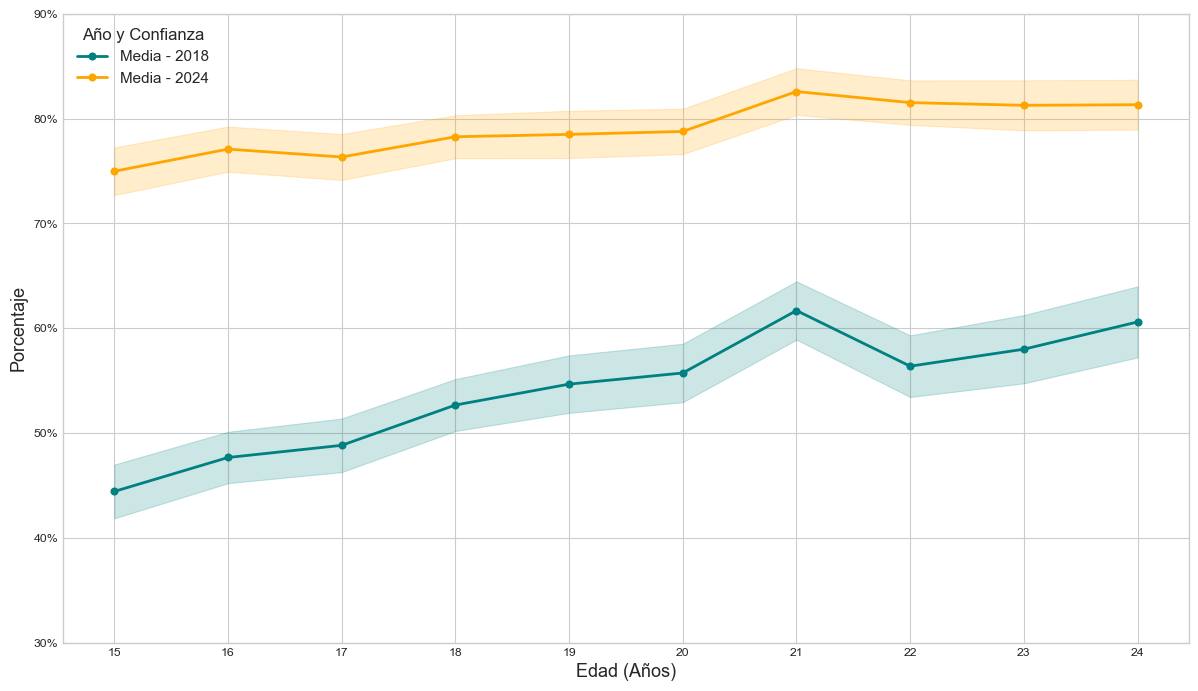

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
import numpy as np
from matplotlib.ticker import PercentFormatter



# === CARGAR DATOS ===
ruta = r"data/processed/Estadistica descriptiva.xlsx"
hoja = "Internet"
df = pd.read_excel(ruta, sheet_name=hoja, header=0)

# === LIMPIAR NOMBRES DE COLUMNAS ===
def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(c for c in unicodedata.normalize("NFD", col) if unicodedata.category(c) != "Mn")
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

# Renombrar columnas
df.rename(columns={
    "anio": "Anio",
    "edad": "Edad",
    "media": "Media",
    "intervalo_de_confianza_inferior": "IC_inf",
    "intervalo_de_confianza_superior": "IC_sup"
}, inplace=True)

# Convertir la columna 'Anio' a string para usarla como categoría (hue)
df['Anio'] = df['Anio'].astype(str)

# --- CONFIGURACIÓN DEL GRÁFICO ---
plt.figure(figsize=(12, 7))
plt.style.use('seaborn-v0_8-whitegrid') # Estilo limpio

# Definir colores para cada año
colores = {
    '2018': 'teal',    # Color del primer subplot
    '2024': 'orange'   # Color del segundo subplot
}

## 📊 Gráfico de Líneas con Bandas de Confianza por Año

# 1. Dibujar las Bandas de Confianza (IC 95%) y la Línea de la Media para cada año

for anio, color in colores.items():
    df_anio = df[df['Anio'] == anio]

    # Banda de confianza (IC 95%)
    plt.fill_between(
        df_anio["Edad"],
        df_anio["IC_inf"],
        df_anio["IC_sup"],
        color=color,
        alpha=0.2,
        label=f"IC 95% - {anio}" # Etiqueta para la leyenda de las bandas
    )
    
    # Línea principal (media)
    plt.plot(
        df_anio["Edad"],
        df_anio["Media"],
        label=f"Media - {anio}", # Etiqueta para la leyenda de las líneas
        color=color,
        marker="o",
        linewidth=2
    )

# 2. Configuración general del gráfico

# --- INSERCIÓN DEL CÓDIGO PARA FORZAR MARCAS EN EL EJE X DE 1 EN 1 ---
min_edad = df['Edad'].min()
max_edad = df['Edad'].max()
marcas_x = np.arange(min_edad, max_edad + 1)
plt.xticks(marcas_x)
# ----------------------------------------------------------------------

# Configuración y etiquetas
#plt.title('Media del Indicador por Edad y Año con Bandas de Confianza del 95%', 
#          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Edad (Años)', fontsize=13)
plt.ylabel('Porcentaje', fontsize=13)

# Ajustar límites del eje Y para una mejor visualización
plt.ylim(0.3, 0.9) 

# Crear una leyenda más clara que combine líneas y bandas
# Para evitar duplicar las etiquetas en la leyenda, se ajusta manualmente.
handles, labels = plt.gca().get_legend_handles_labels()

# Diccionario para agrupar las etiquetas: queremos una sola entrada por año.
unique_labels = {}
for h, l in zip(handles, labels):
    # La etiqueta de la línea es la que queremos usar: 'Media - 2018', 'Media - 2024'
    if 'Media' in l:
        unique_labels[l] = h

# Agregar las etiquetas de las bandas de forma manual (opcional, si quieres las 4 entradas)
# unique_labels['IC 95% - 2018'] = handles[0] # Handle de la primera banda
# unique_labels['IC 95% - 2024'] = handles[1] # Handle de la segunda banda

plt.legend(unique_labels.values(), unique_labels.keys(), 
           title='Año y Confianza', loc='upper left', fontsize=11, title_fontsize=12)

plt.tight_layout() # Ajusta el diseño para que todo quepa
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.show()

# Horas dedicadas al no estudio

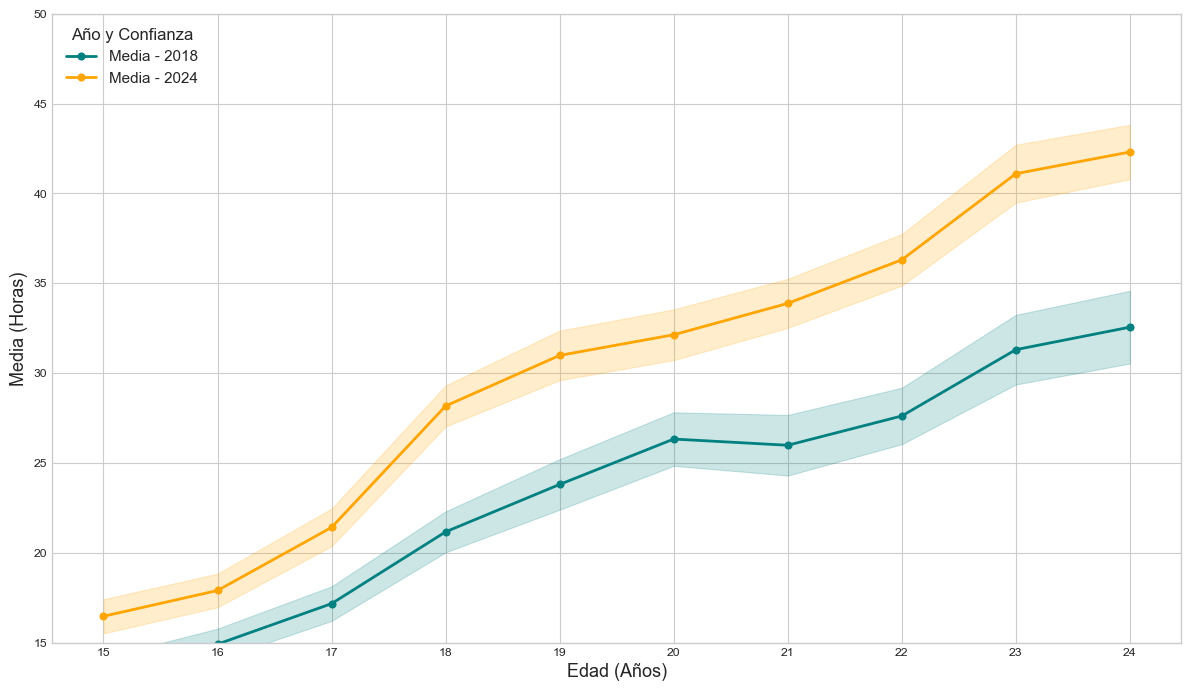

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
import numpy as np # Importado para forzar las marcas del eje X

# === CARGAR DATOS ===
ruta = r"data/processed/Estadistica descriptiva.xlsx"
hoja = "Horas"
df = pd.read_excel(ruta, sheet_name=hoja, header=0)

# === LIMPIAR NOMBRES DE COLUMNAS ===
def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(c for c in unicodedata.normalize("NFD", col) if unicodedata.category(c) != "Mn")
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

# Renombrar columnas
df.rename(columns={
    "anio": "Anio",
    "edad": "Edad",
    "media": "Media",
    "intervalo_de_confianza_inferior": "IC_inf",
    "intervalo_de_confianza_superior": "IC_sup"
}, inplace=True)

# Convertir la columna 'Anio' a string para usarla como categoría (hue)
df['Anio'] = df['Anio'].astype(str)
# NOTA: Se convierte 'Edad' a numérica para los cálculos y ploteo continuo
df['Edad'] = pd.to_numeric(df['Edad']) 

# --- CONFIGURACIÓN DEL GRÁFICO ---
plt.figure(figsize=(12, 7))
plt.style.use('seaborn-v0_8-whitegrid') # Estilo limpio

# Definir colores replicando el diseño solicitado
colores = {
    '2018': 'teal',    # Color del primer diseño
    '2024': 'orange'   # Color del primer diseño
}

## 📊 Gráfico de Líneas con Bandas de Confianza por Año

# 1. Dibujar las Bandas de Confianza (IC 95%) y la Línea de la Media para cada año

for anio, color in colores.items():
    df_anio = df[df['Anio'] == anio]

    # Banda de confianza (IC 95%)
    plt.fill_between(
        df_anio["Edad"],
        df_anio["IC_inf"],
        df_anio["IC_sup"],
        color=color,
        alpha=0.2,
        label=f"IC 95% - {anio}" # Etiqueta para la leyenda de las bandas
    )
    
    # Línea principal (media)
    plt.plot(
        df_anio["Edad"],
        df_anio["Media"],
        label=f"Media - {anio}", # Etiqueta para la leyenda de las líneas
        color=color,
        marker="o",
        linewidth=2
    )

# 2. Configuración general del gráfico

# --- CÓDIGO PARA FORZAR MARCAS EN EL EJE X DE 1 EN 1 ---
min_edad = df['Edad'].min()
max_edad = df['Edad'].max()
marcas_x = np.arange(min_edad, max_edad + 1)
plt.xticks(marcas_x)
# --------------------------------------------------------

# Configuración y etiquetas
#plt.title('Media de Horas por Edad y Año con Bandas de Confianza del 95%', 
#          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Edad (Años)', fontsize=13)
plt.ylabel('Media (Horas)', fontsize=13) # Etiqueta del eje Y de la gráfica original de Horas

# Ajustar límites del eje Y para una mejor visualización
plt.ylim(15, 50) # Límites del eje Y de la gráfica original de Horas

# Crear una leyenda más clara que combine líneas y bandas
# Se mantiene la lógica para mostrar solo las entradas de "Media"
handles, labels = plt.gca().get_legend_handles_labels()
unique_labels = {}
for h, l in zip(handles, labels):
    if 'Media' in l:
        unique_labels[l] = h

plt.legend(unique_labels.values(), unique_labels.keys(), 
           title='Año y Confianza', loc='upper left', fontsize=11, title_fontsize=12)

plt.tight_layout() # Ajusta el diseño para que todo quepa
plt.show()

# Asistencia por Region


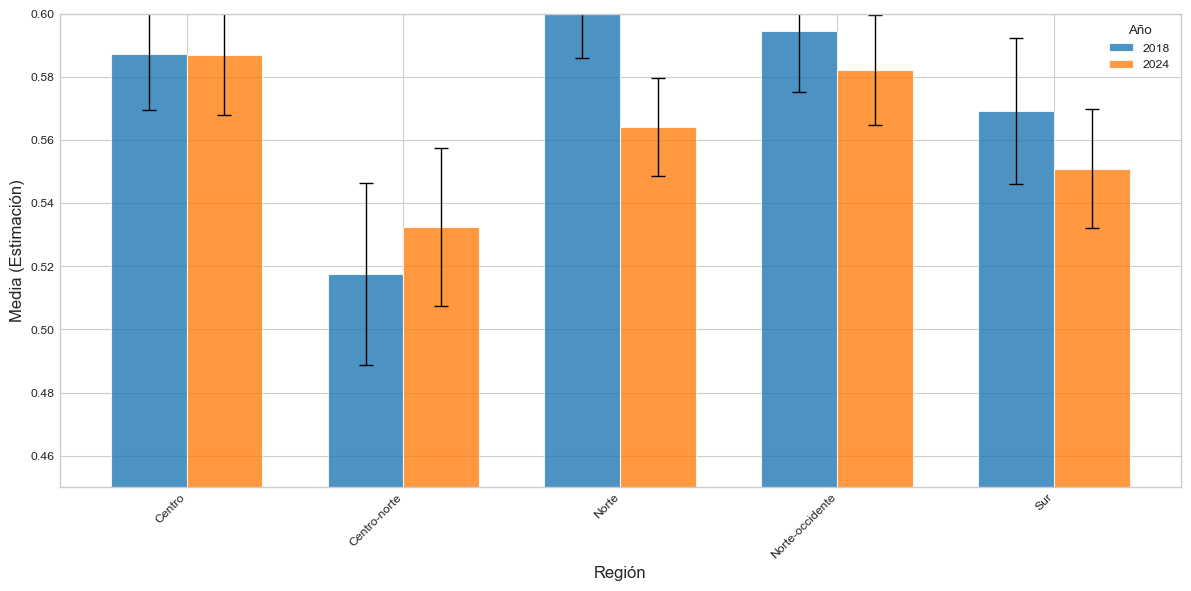

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
import numpy as np # Importado para forzar las marcas del eje X

# === CARGAR DATOS ===
ruta = r"data/processed/Estadistica descriptiva.xlsx"
hoja = "Region"
df = pd.read_excel(ruta, sheet_name=hoja, header=0)

# === LIMPIAR NOMBRES DE COLUMNAS ===
def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(c for c in unicodedata.normalize("NFD", col) if unicodedata.category(c) != "Mn")
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

# Renombrar columnas
df.rename(columns={
    "anio": "Anio",
    "region": "Region",
    "media": "Media",
    "intervalo_de_confianza_inferior": "IC_inf",
    "intervalo_de_confianza_superior": "IC_sup"
}, inplace=True)

# Convertir la columna 'Anio' a string para usarla como categoría (hue)
df['Anio'] = df['Anio'].astype(str)

# === GENERACIÓN DEL GRÁFICO ===

# 1. Calcular la diferencia entre la media y los límites del intervalo de confianza
# El error inferior es Media - IC_inf
df['yerr_inf'] = df['Media'] - df['IC_inf']
# El error superior es IC_sup - Media
df['yerr_sup'] = df['IC_sup'] - df['Media']

# Combinar los errores superior e inferior en un array de 2xN para Matplotlib
# Matplotlib espera [[error_inf_1, error_inf_2, ...], [error_sup_1, error_sup_2, ...]]
yerr = np.array([df['yerr_inf'].values, df['yerr_sup'].values])

# 2. Definir el ancho de las barras y las posiciones
bar_width = 0.35
# Obtener las regiones únicas para usarlas como etiquetas del eje X
regions = df['Region'].unique()
# Posiciones base para el eje X
x_base = np.arange(len(regions))

# 3. Separar los datos por año
df_2018 = df[df['Anio'] == '2018'].sort_values('Region')
df_2024 = df[df['Anio'] == '2024'].sort_values('Region')

# Asegúrate de que el orden de las regiones sea el mismo en ambos DataFrames
# y que el orden de yerr para cada año coincida con el orden de las Medias
yerr_2018 = np.array([df_2018['yerr_inf'].values, df_2018['yerr_sup'].values])
yerr_2024 = np.array([df_2024['yerr_inf'].values, df_2024['yerr_sup'].values])


# 4. Crear la figura y los ejes
plt.style.use('seaborn-v0_8-whitegrid') # Estilo para un fondo más limpio
fig, ax = plt.subplots(figsize=(12, 6))

# 5. Dibujar las barras para 2018
rects1 = ax.bar(
    x_base - bar_width/2, # Desplazar la barra de 2018 a la izquierda
    df_2018['Media'],
    bar_width,
    label='2018',
    yerr=yerr_2018, # Barras de error para el IC
    capsize=5, # Tamaño de las tapas de las barras de error
    color='#1f77b4', # Color por defecto de matplotlib (azul)
    alpha=0.8,
    error_kw={'ecolor': 'black', 'lw': 1, 'capthick': 1} # Estilo de las barras de error
)

# 6. Dibujar las barras para 2024
rects2 = ax.bar(
    x_base + bar_width/2, # Desplazar la barra de 2024 a la derecha
    df_2024['Media'],
    bar_width,
    label='2024',
    yerr=yerr_2024, # Barras de error para el IC
    capsize=5,
    color='#ff7f0e', # Color por defecto de matplotlib (naranja)
    alpha=0.8,
    error_kw={'ecolor': 'black', 'lw': 1, 'capthick': 1}
)

# 7. Configuración del gráfico
# Título y etiquetas
#ax.set_title('Media Regional por Año con Intervalo de Confianza del 95%', fontsize=16)
ax.set_ylabel('Media (Estimación)', fontsize=12)
ax.set_xlabel('Región', fontsize=12)

# Marcas y etiquetas del eje X
ax.set_xticks(x_base)
ax.set_xticklabels(regions, rotation=45, ha="right") # Rotar etiquetas para mejor lectura

# Leyenda
ax.legend(title='Año')

# Líneas de referencia para una lectura más fácil (opcional, ya cubierto por el estilo whitegrid)
# ax.grid(axis='y', linestyle='--', alpha=0.7)

# Límites del eje Y (ajustar si es necesario)
# En el ejemplo el rango de Medias va de ~0.47 a ~0.59, por lo que 0.45 a 0.6 es un buen rango.
ax.set_ylim(0.45, 0.60) 

# Añadir las etiquetas de la Media en la parte superior de las barras (opcional)
def autolabel(rects, df_data):
    for i, rect in enumerate(rects):
        height = rect.get_height()
        # Usa el valor de la columna 'Media' del DataFrame
        ax.annotate(
            f'{height:.3f}', # Formato con 3 decimales
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),  # 3 puntos de offset vertical
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=9
        )

# autolabel(rects1, df_2018)
# autolabel(rects2, df_2024)


# Mostrar el gráfico
plt.tight_layout() # Ajustar el diseño para que las etiquetas no se corten
plt.show()

# Asistencia por trabajo

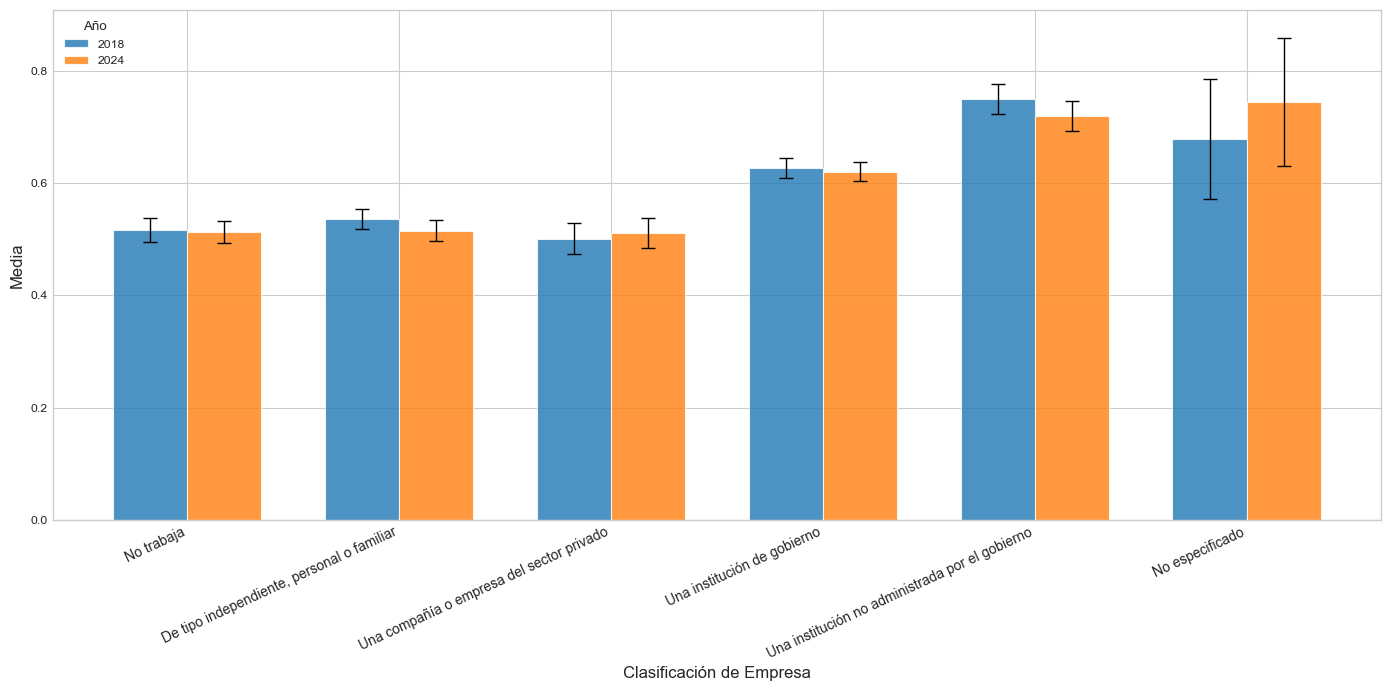

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
import numpy as np # Importado para forzar las marcas del eje X

# === CARGAR DATOS ===
ruta = r"data/processed/Estadistica descriptiva.xlsx"
hoja = "Trabajos"
df = pd.read_excel(ruta, sheet_name=hoja, header=0)

# === LIMPIAR NOMBRES DE COLUMNAS ===
def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(c for c in unicodedata.normalize("NFD", col) if unicodedata.category(c) != "Mn")
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

# Renombrar columnas
df.rename(columns={
    "anio": "Anio",
    "clasificacion_empresa": "Clasificacion_empresa",
    "media": "Media",
    "intervalo_de_confianza_inferior": "IC_inf",
    "intervalo_de_confianza_superior": "IC_sup"
}, inplace=True)

# Convertir la columna 'Anio' a string para usarla como categoría (hue)
df['Anio'] = df['Anio'].astype(str)

# 1. Calcular la diferencia entre la media y los límites del intervalo de confianza
df['yerr_inf'] = df['Media'] - df['IC_inf'] # Error inferior es Media - IC_inf
df['yerr_sup'] = df['IC_sup'] - df['Media'] # Error superior es IC_sup - Media

# 2. Definir el ancho de las barras y las posiciones
bar_width = 0.35
# Obtener las categorías únicas para las etiquetas del eje X
categorias = df['Clasificacion_empresa'].unique()
# Posiciones base para el eje X
x_base = np.arange(len(categorias))

# 3. Separar los datos por año
# Es crucial ordenar por la columna de la categoría para asegurar que los índices de x_base,
# Media y yerr coincidan.
df_2018 = df[df['Anio'] == '2018'].sort_values('Clasificacion_empresa')
df_2024 = df[df['Anio'] == '2024'].sort_values('Clasificacion_empresa')

# 4. Crear los arrays de error para Matplotlib
yerr_2018 = np.array([df_2018['yerr_inf'].values, df_2018['yerr_sup'].values])
yerr_2024 = np.array([df_2024['yerr_inf'].values, df_2024['yerr_sup'].values])


# === GENERACIÓN DEL GRÁFICO ===

# 1. Crear la figura y los ejes
#plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 7)) # Aumentar el tamaño horizontal para las etiquetas

# 2. Dibujar las barras para 2018
rects1 = ax.bar(
    x_base - bar_width/2, # Desplazar la barra de 2018 a la izquierda
    df_2018['Media'],
    bar_width,
    label='2018',
    yerr=yerr_2018, # Barras de error para el IC
    capsize=5,
    color='#1f77b4', # Azul
    alpha=0.8,
    error_kw={'ecolor': 'black', 'lw': 1, 'capthick': 1}
)

# 3. Dibujar las barras para 2024
rects2 = ax.bar(
    x_base + bar_width/2, # Desplazar la barra de 2024 a la derecha
    df_2024['Media'],
    bar_width,
    label='2024',
    yerr=yerr_2024, # Barras de error para el IC
    capsize=5,
    color='#ff7f0e', # Naranja
    alpha=0.8,
    error_kw={'ecolor': 'black', 'lw': 1, 'capthick': 1}
)

# 4. Configuración del gráfico
# Título y etiquetas
#ax.set_title('Media por Clasificación de Empresa y Año (IC 95%)', fontsize=16)
ax.set_ylabel('Media', fontsize=12)
ax.set_xlabel('Clasificación de Empresa', fontsize=12)

# Marcas y etiquetas del eje X
ax.set_xticks(x_base)
# Usar las categorías para las etiquetas, rotadas para mejor lectura
ax.set_xticklabels(categorias, rotation=25, ha="right", fontsize=10) 

# Leyenda
ax.legend(title='Año', loc='upper left')

# Límites del eje Y: El rango de Medias va de ~0.47 a ~0.74, o hasta 0.85 con el error
# Se usa un rango que muestre los datos claramente.
y_min = min(df['IC_inf'].min() - 0.05, 0)
y_max = df['IC_sup'].max() + 0.05
ax.set_ylim(y_min, y_max) 

# Función para añadir las etiquetas de la Media en la parte superior de las barras
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(
            f'{height:.3f}',
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3), 
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=8 # Tamaño de fuente reducido
        )

# Añadir las etiquetas de la Media
#autolabel(rects1)
#autolabel(rects2)


# Mostrar el gráfico
plt.tight_layout()
plt.show()


# Razones para no asistir al escuela

/var/folders/lw/wsksmjcd29scklkcylgwjjlr0000gn/T/ipykernel_59550/2979081639.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('GnBu') # Puedes cambiar 'GnBu' por 'Blues', 'Teal' o 'viridis'


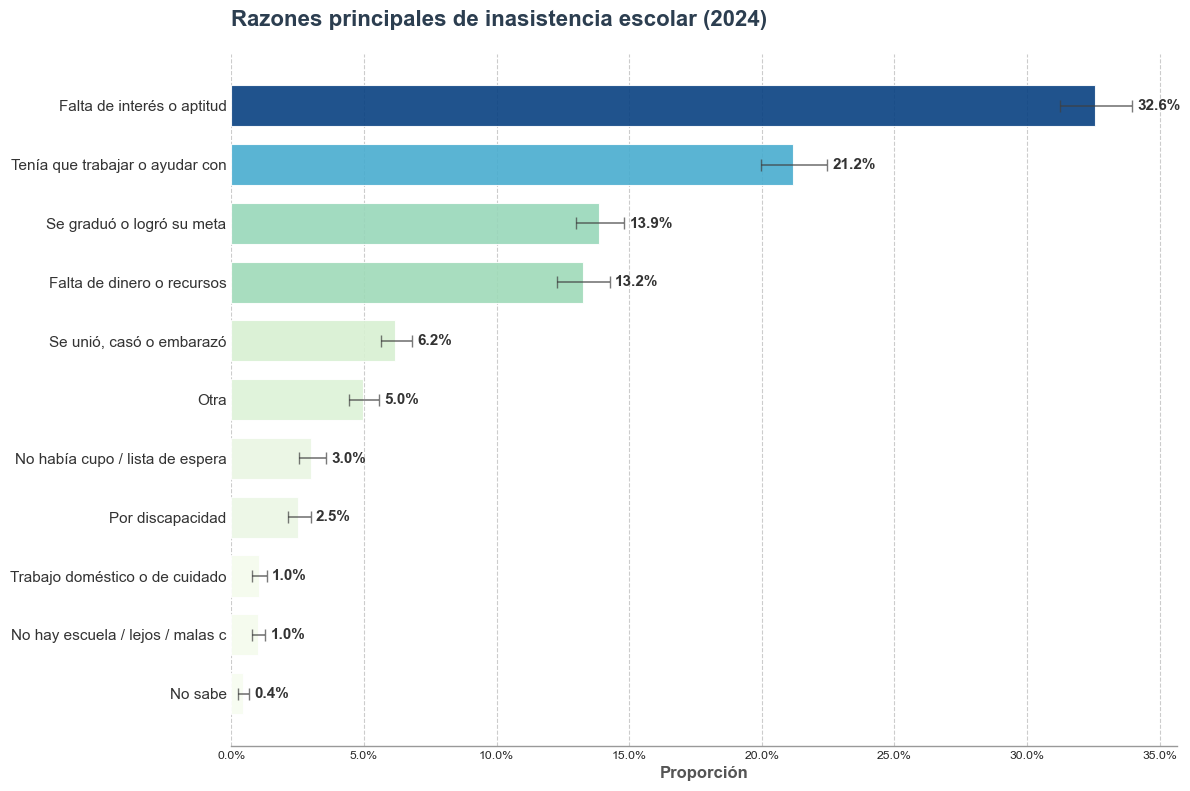

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
import numpy as np
from matplotlib.ticker import PercentFormatter
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# === 1. CARGAR DATOS ===
ruta = r"data/processed/Estadistica descriptiva.xlsx"
hoja = "No asistencia escolar"
df = pd.read_excel(ruta, sheet_name=hoja, header=0)

# === 2. LIMPIEZA DE DATOS (Tu lógica original) ===
def limpiar_columna(col):
    col = col.strip().lower().replace(" ", "_")
    col = "".join(c for c in unicodedata.normalize("NFD", col) if unicodedata.category(c) != "Mn")
    return col

df.columns = [limpiar_columna(c) for c in df.columns]

# Renombrar columnas
df.rename(columns={
    "anio": "Anio",
    "razon": "Razon",
    "media": "Media",
    "intervalo_de_confianza_inferior": "IC_inf",
    "intervalo_de_confianza_superior": "IC_sup"
}, inplace=True)

df['Anio'] = df['Anio'].astype(str)

# === 3. PREPARACIÓN PARA EL GRÁFICO ===
# Calcular los errores asimétricos para las barras de error
df['Error_xerr_neg'] = df['Media'] - df['IC_inf']
df['Error_xerr_pos'] = df['IC_sup'] - df['Media']

# Ordenar los datos: Importante para que la barra mayor salga arriba
df_sorted = df.sort_values(by='Media', ascending=True).reset_index(drop=True)

# === 4. CREACIÓN DEL GRÁFICO MEJORADO ===

# Configuración de fuente y estilo base
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Calibri', 'DejaVu Sans']

# Crear figura con fondo blanco limpio
fig, ax = plt.subplots(figsize=(12, 8), facecolor='white')

# -- PALETA DE COLORES --
# Creamos un mapa de color basado en los valores (las barras grandes serán más oscuras)
norm = mcolors.Normalize(vmin=df_sorted['Media'].min(), vmax=df_sorted['Media'].max())
cmap = cm.get_cmap('GnBu') # Puedes cambiar 'GnBu' por 'Blues', 'Teal' o 'viridis'
colores = cmap(norm(df_sorted['Media']))

# Generar barras horizontales
bars = ax.barh(
    y=df_sorted['Razon'],
    width=df_sorted['Media'],
    color=colores,
    height=0.7,  # Barras un poco más delgadas para elegancia
    alpha=0.9,   # Ligera transparencia
    # Agregamos las barras de error (Intervalos de Confianza)
    xerr=[df_sorted['Error_xerr_neg'], df_sorted['Error_xerr_pos']],
    capsize=4,   # Remates verticales en la línea de error
    error_kw={'ecolor': '#404040', 'linewidth': 1.2, 'alpha': 0.7}
)

# === 5. DETALLES DE DISEÑO ===

# Título y etiquetas estilizados
ax.set_title('Razones principales de inasistencia escolar (2024)', 
             fontsize=16, fontweight='bold', color='#2c3e50', loc='left', pad=20)
ax.set_xlabel('Proporción', fontsize=12, fontweight='bold', color='#555555')
# ax.set_ylabel('Razón') # Opcional: a veces es redundante poner "Razón"

# Eje X en porcentaje
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

# Limpieza visual (Data-Ink Ratio)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False) # Quitamos la línea vertical izquierda
ax.spines['bottom'].set_color('#999999')

# Grid vertical suave
ax.grid(axis='x', linestyle='--', alpha=0.4, color='gray')
ax.grid(axis='y', visible=False)

# Etiquetas de valores al final de las barras
for i, bar in enumerate(bars):
    width = bar.get_width()
    # Obtenemos el error positivo específico de esa barra para posicionar el texto
    error_val = df_sorted['Error_xerr_pos'].iloc[i]
    
    # Posición del texto: Ancho de barra + Error + un margen pequeño
    x_pos = width + error_val + 0.002
    
    ax.text(
        x_pos, 
        bar.get_y() + bar.get_height()/2.0,
        f'{width:.1%}', 
        ha='left', 
        va='center', 
        fontsize=11, 
        fontweight='bold', 
        color='#333333'
    )

# Ajustar etiquetas del eje Y (Categorías)
ax.tick_params(axis='y', length=0, labelsize=11, labelcolor='#333333')

# Ajustar diseño final
plt.tight_layout()

# Mostrar gráfico
plt.show()